In [1]:
# ===================== CELL 1: DATASET INSPECTION =====================
import os, time, csv, zipfile, collections
import pandas as pd

t0 = time.perf_counter()

DATA_PATH = "/kaggle/input/datasets/mrithulavjmp/time-sequence"
OUT_DIR   = "/kaggle/working/"

# ---- 1. Verify path ----
print("Path exists:", os.path.exists(DATA_PATH))
if not os.path.exists(DATA_PATH):
    print("\nPath not found. Contents of /kaggle/input:")
    for root, dirs, files in os.walk("/kaggle/input"):
        print(root)
        if root.count(os.sep) > 4:
            dirs[:] = []
    raise SystemExit("Fix DATA_PATH and re-run.")

# ---- 2. Walk the directory (only reads names and sizes, not contents) ----
all_files = []   # (path, size_bytes, extension)
for root, dirs, files in os.walk(DATA_PATH):
    for f in files:
        p = os.path.join(root, f)
        try:
            s = os.path.getsize(p)
        except OSError:
            s = 0
        ext = os.path.splitext(f)[1].lower() or "(none)"
        all_files.append((p, s, ext))

total_bytes = sum(s for _, s, _ in all_files)
print(f"\nTotal files : {len(all_files):,}")
print(f"Total size  : {total_bytes/1024**2:,.1f} MB ({total_bytes/1024**3:.2f} GB)")

# ---- 3. Top-level folders ----
print("\nTOP-LEVEL ITEMS:")
for name in sorted(os.listdir(DATA_PATH)):
    full = os.path.join(DATA_PATH, name)
    if os.path.isdir(full):
        n = sum(1 for p, _, _ in all_files if p.startswith(full + os.sep))
        sz = sum(s for p, s, _ in all_files if p.startswith(full + os.sep))
        print(f"  [DIR]  {name:40s} files={n:,}  size={sz/1024**2:,.1f} MB")
    else:
        print(f"  [FILE] {name:40s} size={os.path.getsize(full)/1024**2:,.2f} MB")

# ---- 4. Count by extension ----
ext_count = collections.Counter(e for _, _, e in all_files)
ext_size  = collections.defaultdict(int)
for _, s, e in all_files:
    ext_size[e] += s
print("\nFILES BY EXTENSION:")
for e, c in ext_count.most_common():
    print(f"  {e:10s} count={c:,}  size={ext_size[e]/1024**2:,.1f} MB")

# ---- 5. Guess AVL / LTI / GTFS from folder or file names ----
def tag(path):
    low = path.lower()
    tags = []
    for key in ["avl", "lti", "gtfs"]:
        if key in low:
            tags.append(key.upper())
    for key in ["board", "alight", "load", "passenger", "apc", "ticket"]:
        if key in low:
            tags.append("LOAD/BOARDING?")
            break
    return tags

groups = collections.defaultdict(list)
for p, s, e in all_files:
    for t in tag(p[len(DATA_PATH):]):
        groups[t].append((p, s))

print("\nLIKELY GROUPS (based on names only, to be confirmed with contents):")
for g in ["AVL", "LTI", "GTFS", "LOAD/BOARDING?"]:
    items = groups.get(g, [])
    print(f"\n  {g}: {len(items):,} files, {sum(s for _, s in items)/1024**2:,.1f} MB")
    for p, s in items[:8]:
        print(f"     {p[len(DATA_PATH):]}  ({s/1024:,.1f} KB)")
    if len(items) > 8:
        print(f"     ... and {len(items)-8:,} more")

# ---- 6. Standard GTFS files ----
std_gtfs = ["agency.txt", "routes.txt", "stops.txt", "trips.txt", "stop_times.txt",
            "shapes.txt", "calendar.txt", "calendar_dates.txt", "frequencies.txt",
            "transfers.txt", "feed_info.txt"]
names_found = collections.defaultdict(list)
for p, s, e in all_files:
    names_found[os.path.basename(p).lower()].append(p)
print("\nSTANDARD GTFS FILES:")
for g in std_gtfs:
    hits = names_found.get(g, [])
    print(f"  {g:20s} {'FOUND x'+str(len(hits)) if hits else 'not found'}")
    for h in hits[:2]:
        print(f"       {h[len(DATA_PATH):]}")

# ---- 7. Safe peek into a few files (first rows only) ----
def peek_file(path, nrows=3):
    ext = os.path.splitext(path)[1].lower()
    print("\n" + "=" * 70)
    print("FILE:", path[len(DATA_PATH):], f"({os.path.getsize(path)/1024**2:,.2f} MB)")
    try:
        if ext in (".csv", ".txt", ".tsv", ".dat", ""):
            with open(path, "r", errors="replace") as fh:
                head = fh.read(4096)
            try:
                delim = csv.Sniffer().sniff(head.split("\n", 1)[0] + "\n").delimiter
            except Exception:
                delim = ","
            print("Detected delimiter:", repr(delim))
            df = pd.read_csv(path, nrows=nrows, sep=delim, low_memory=False, on_bad_lines="skip")
            print("Columns:", list(df.columns))
            print("Dtypes :", dict(df.dtypes.astype(str)))
            print(df.to_string(max_colwidth=30))
        elif ext == ".parquet":
            import pyarrow.parquet as pq
            pf = pq.ParquetFile(path)
            print("Rows:", pf.metadata.num_rows, "| Columns:", pf.schema_arrow.names)
            print(pf.read_row_group(0).to_pandas().head(nrows).to_string(max_colwidth=30))
        elif ext == ".zip":
            with zipfile.ZipFile(path) as z:
                names = z.namelist()
                print("Zip contains", len(names), "entries. First 10:", names[:10])
        elif ext in (".json", ".jsonl"):
            with open(path, "r", errors="replace") as fh:
                print(fh.read(600))
        else:
            print("Extension not handled in Cell 1:", ext)
    except Exception as ex:
        print("Could not read:", type(ex).__name__, ex)

# choose peek candidates: up to 2 per group, plus up to 3 unique-extension files
candidates, seen = [], set()
for g in ["AVL", "LTI", "GTFS", "LOAD/BOARDING?"]:
    for p, s in sorted(groups.get(g, []), key=lambda x: x[1])[:1] + sorted(groups.get(g, []), key=lambda x: -x[1])[:1]:
        if p not in seen:
            seen.add(p); candidates.append(p)
for p, s, e in all_files:
    if len(candidates) >= 12: break
    if p not in seen and e in (".csv", ".txt", ".parquet", ".zip", ".json") :
        seen.add(p); candidates.append(p)

print(f"\nPeeking into {len(candidates)} candidate files (first rows only)...")
for p in candidates[:12]:
    peek_file(p)

print(f"\nCell 1 wall time: {time.perf_counter()-t0:.1f} s")

Path exists: True

Total files : 1,063
Total size  : 3,669.2 MB (3.58 GB)

TOP-LEVEL ITEMS:
  [DIR]  Time Travel                              files=1,063  size=3,669.2 MB

FILES BY EXTENSION:
  .parquet   count=1,043  size=3,564.6 MB
  .txt       count=19  size=104.6 MB
  .ipynb     count=1  size=0.0 MB

LIKELY GROUPS (based on names only, to be confirmed with contents):

  AVL: 686 files, 3,344.7 MB
     /Time Travel/AVL/avl-lines-2024-09-01.parquet  (467.7 KB)
     /Time Travel/AVL/avl-vehicles-2024-12-18.parquet  (10,687.1 KB)
     /Time Travel/AVL/avl-lines-2025-03-17.parquet  (545.8 KB)
     /Time Travel/AVL/avl-lines-2024-06-21.parquet  (449.7 KB)
     /Time Travel/AVL/avl-vehicles-2024-09-20.parquet  (11,184.8 KB)
     /Time Travel/AVL/avl-lines-2024-04-19.parquet  (433.1 KB)
     /Time Travel/AVL/avl-vehicles-2025-03-17.parquet  (12,000.7 KB)
     /Time Travel/AVL/avl-lines-2024-10-24.parquet  (504.8 KB)
     ... and 678 more

  LTI: 357 files, 219.9 MB
     /Time Travel/LTI/lt

In [2]:
# ===================== CELL 2: SCHEMA SURVEY (METADATA ONLY) =====================
import os, re, time, collections
import pandas as pd
import pyarrow.parquet as pq

t0 = time.perf_counter()
ROOT = "/kaggle/input/datasets/mrithulavjmp/time-sequence/Time Travel"

# ---------- A. Parquet schema survey (reads only footers, not data) ----------
def survey(folder, prefix):
    files = sorted(f for f in os.listdir(folder) if f.startswith(prefix) and f.endswith(".parquet"))
    groups = collections.OrderedDict()   # signature -> info
    dates, bad = [], []
    total_rows = 0
    for f in files:
        m = re.search(r"(\d{4}-\d{2}-\d{2})", f)
        d = m.group(1) if m else None
        try:
            pf = pq.ParquetFile(os.path.join(folder, f))
            schema = pf.schema_arrow
            sig = tuple((n, str(t)) for n, t in zip(schema.names, schema.types))
            nrows = pf.metadata.num_rows
        except Exception as ex:
            bad.append((f, str(ex)[:80])); continue
        total_rows += nrows
        dates.append(d)
        g = groups.setdefault(sig, {"files": 0, "first": d, "last": d, "rows": 0})
        g["files"] += 1; g["rows"] += nrows
        g["first"] = min(g["first"], d); g["last"] = max(g["last"], d)
    return files, groups, sorted(x for x in dates if x), total_rows, bad

for name, prefix in [("AVL vehicles", "avl-vehicles-"), ("AVL lines", "avl-lines-"), ("LTI", "lti-")]:
    folder = os.path.join(ROOT, "LTI" if prefix == "lti-" else "AVL")
    files, groups, dates, total_rows, bad = survey(folder, prefix)
    print("=" * 78)
    print(f"{name}: {len(files)} files | total rows {total_rows:,} | unique days {len(set(dates))}")
    if dates:
        print(f"  date range: {dates[0]}  ->  {dates[-1]}")
        all_days = pd.date_range(dates[0], dates[-1]).strftime("%Y-%m-%d")
        missing = sorted(set(all_days) - set(dates))
        print(f"  calendar days with NO file: {len(missing)}", missing[:15], "..." if len(missing) > 15 else "")
        per_month = collections.Counter(d[:7] for d in dates)
        print("  files per month:", dict(sorted(per_month.items())))
    if bad: print("  UNREADABLE:", bad[:5])
    print(f"  distinct schemas: {len(groups)}")
    for i, (sig, g) in enumerate(groups.items(), 1):
        print(f"\n  --- Schema #{i}: {g['files']} files, {g['rows']:,} rows, {g['first']} -> {g['last']}")
        for n, t in sig:
            print(f"       {n:32s} {t}")

# ---------- B. GTFS survey (BUS and BRT) ----------
def count_lines(path):
    n = 0
    with open(path, "rb") as fh:
        while True:
            b = fh.read(1 << 24)
            if not b: break
            n += b.count(b"\n")
    return n - 1

for feed in ["BUS", "BRT"]:
    gdir = os.path.join(ROOT, "GTFS", feed)
    print("\n" + "=" * 78)
    print("GTFS", feed, "->", sorted(os.listdir(gdir)))
    for fn in ["agency.txt", "feed_info.txt", "routes.txt", "calendar.txt", "calendar_dates.txt",
               "frequencies.txt", "trips.txt", "stops.txt", "stop_times.txt", "shapes.txt"]:
        p = os.path.join(gdir, fn)
        if not os.path.exists(p):
            print(f"\n[{fn}] not present"); continue
        rows = count_lines(p)
        df = pd.read_csv(p, nrows=3, low_memory=False)
        print(f"\n[{fn}] rows={rows:,}  columns={list(df.columns)}")
        if fn in ("agency.txt", "feed_info.txt", "calendar.txt", "routes.txt", "frequencies.txt"):
            print(df.to_string(max_colwidth=28))

# ---------- C. GTFS facts that matter for the graph ----------
gdir = os.path.join(ROOT, "GTFS", "BUS")
trips = pd.read_csv(os.path.join(gdir, "trips.txt"), low_memory=False)
routes = pd.read_csv(os.path.join(gdir, "routes.txt"), low_memory=False)
stops = pd.read_csv(os.path.join(gdir, "stops.txt"), low_memory=False)
print("\n" + "=" * 78)
print("BUS GTFS counts -> routes:", routes.shape[0], "| trips:", trips.shape[0], "| stops:", stops.shape[0])
print("trips.txt columns:", list(trips.columns))
print(trips.head(3).to_string(max_colwidth=25))
print("\nstops.txt columns:", list(stops.columns))
print(stops.head(3).to_string(max_colwidth=25))
print("\nroutes.route_short_name examples:", routes["route_short_name"].astype(str).head(10).tolist())
print("calendar service_ids in trips:", trips["service_id"].nunique() if "service_id" in trips else "n/a")

print(f"\nCell 2 wall time: {time.perf_counter()-t0:.1f} s")

AVL vehicles: 323 files | total rows 752,477,088 | unique days 323
  date range: 2024-03-01  ->  2025-03-31
  calendar days with NO file: 73 ['2024-04-11', '2024-04-16', '2024-04-22', '2024-04-23', '2024-04-24', '2024-06-30', '2024-07-28', '2024-07-29', '2024-07-30', '2024-07-31', '2024-08-01', '2024-08-02', '2024-08-03', '2024-08-04', '2024-08-05'] ...
  files per month: {'2024-03': 31, '2024-04': 25, '2024-05': 31, '2024-06': 29, '2024-07': 27, '2024-09': 27, '2024-10': 8, '2024-11': 29, '2024-12': 28, '2025-01': 30, '2025-02': 28, '2025-03': 30}
  distinct schemas: 3

  --- Schema #1: 56 files, 129,216,571 rows, 2024-03-01 -> 2024-04-30
       vehicle                          int32
       route_short_name                 string
       direction_id                     dictionary<values=string, indices=int8, ordered=0>
       gps_datetime                     timestamp[ms]
       longitude                        float
       latitude                         float
       stop_id        

In [3]:
# ===================== CELL 3: ONE-DAY DEEP LOOK AT AVL VEHICLES =====================
import os, re, time
import numpy as np, pandas as pd
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)

t0 = time.perf_counter()
ROOT = "/kaggle/input/datasets/mrithulavjmp/time-sequence/Time Travel"
DAY  = "2024-09-20"

veh = pd.read_parquet(f"{ROOT}/AVL/avl-vehicles-{DAY}.parquet")
print("shape:", veh.shape, "| memory MB:", round(veh.memory_usage(deep=True).sum()/1024**2, 1))
print("\nDtypes:\n", veh.dtypes.astype(str).to_string())
print("\nMissing values:\n", veh.isna().sum().to_string())
print("\nFully duplicated rows:", int(veh.duplicated().sum()))
print("\nDay of week:", pd.Timestamp(DAY).day_name())
print("gps_datetime min/max:", veh["gps_datetime"].min(), "|", veh["gps_datetime"].max())

# ---- 1. What is in the columns ----
print("\nvehicles:", veh["vehicle"].nunique(), "| routes:", veh["route_short_name"].nunique(),
      "| service_codes:", veh["service_code"].nunique(), "| stop_ids:", veh["stop_id"].nunique())
print("\ndirection_id counts:\n", veh["direction_id"].astype(str).value_counts(dropna=False).to_string())
if "TipoViagem" in veh:
    print("\nTipoViagem counts:\n", veh["TipoViagem"].value_counts(dropna=False).to_string())
for c in ["DataHoraGPSEntrada", "DataHoraGPSSaida"]:
    if c in veh:
        nn = veh[c].notna().sum()
        print(f"\n{c}: non-null = {nn:,} ({nn/len(veh)*100:.2f}%)")
        if nn: print(veh.loc[veh[c].notna(), ["vehicle","gps_datetime","stop_id","DataHoraGPSEntrada","DataHoraGPSSaida"]].head(5).to_string())
print("\nRoute name examples:", veh["route_short_name"].drop_duplicates().head(15).tolist())

# ---- 2. Ping frequency per vehicle ----
veh = veh.sort_values(["vehicle", "gps_datetime"]).reset_index(drop=True)
same_v = veh["vehicle"].eq(veh["vehicle"].shift())
dt = veh["gps_datetime"].diff().dt.total_seconds().where(same_v)
print("\nSeconds between consecutive pings (same vehicle):")
print(dt.describe(percentiles=[.05,.25,.5,.75,.95,.99]).round(1).to_string())
print(f"  == 0 s: {(dt==0).mean()*100:.1f}% | <=10 s: {(dt<=10).mean()*100:.1f}% | >60 s: {(dt>60).mean()*100:.1f}% | >300 s: {(dt>300).mean()*100:.2f}%")

# ---- 3. What does stop_id mean? Collapse consecutive pings with the same stop_id into 'runs' ----
key_change = (~same_v) | veh["stop_id"].ne(veh["stop_id"].shift()) \
             | veh["route_short_name"].ne(veh["route_short_name"].shift()) \
             | veh["direction_id"].astype(str).ne(veh["direction_id"].astype(str).shift()) \
             | veh["service_code"].ne(veh["service_code"].shift())
veh["run_id"] = key_change.cumsum()
runs = veh.groupby("run_id").agg(vehicle=("vehicle","first"), route=("route_short_name","first"),
        direction=("direction_id", lambda s: str(s.iloc[0])), service_code=("service_code","first"),
        stop_id=("stop_id","first"), t_first=("gps_datetime","min"), t_last=("gps_datetime","max"),
        n_pings=("gps_datetime","size"))
runs["span_s"] = (runs["t_last"] - runs["t_first"]).dt.total_seconds()
print("\nNumber of runs (consecutive same stop_id):", f"{len(runs):,}", "for", f"{len(veh):,}", "pings")
print("Pings per run:\n", runs["n_pings"].describe(percentiles=[.5,.9,.99]).round(1).to_string())
print("Run span seconds:\n", runs["span_s"].describe(percentiles=[.5,.9,.99]).round(1).to_string())

# one example vehicle (median number of rows)
cnt = veh["vehicle"].value_counts()
vsel = cnt.index[len(cnt)//2]
print(f"\nEXAMPLE vehicle {vsel}: first 35 runs")
ex = runs[runs["vehicle"] == vsel].head(35)
print(ex[["route","direction","service_code","stop_id","t_first","t_last","n_pings","span_s"]].to_string())

# ---- 4. Compare with the AVL 'lines' file of the same day (planned stop order) ----
lines_path = f"{ROOT}/AVL/avl-lines-{DAY}.parquet"
lines = pd.read_parquet(lines_path) if os.path.exists(lines_path) else None
if lines is not None:
    print("\nAVL lines shape:", lines.shape, "| stop_id NaN:", int(lines["stop_id"].isna().sum()))
    r0, d0, s0 = ex.iloc[0][["route","direction","service_code"]]
    sub = lines[(lines["route_short_name"].astype(str)==str(r0)) & (lines["direction_id"].astype(str)==str(d0)) & (lines["service_code"]==s0)] \
          .sort_values("pt_sequence")
    print(f"\nPlanned points for route={r0} dir={d0} service_code={s0}: {len(sub)} rows")
    print(sub[["pt_sequence","stop_id","latitude","longitude"]].head(25).to_string())

# ---- 5. Do keys overlap with GTFS? ----
def norm_route(x):
    s = str(x).strip()
    if re.fullmatch(r"\d+\.0", s): s = s[:-2]
    return s.lstrip("0") or "0"
gs = pd.read_csv(f"{ROOT}/GTFS/BUS/stops.txt", dtype=str)
gstops = set(gs.loc[~gs["stop_id"].str.endswith("_S"), "stop_id"])
gr = pd.read_csv(f"{ROOT}/GTFS/BUS/routes.txt", dtype=str)
groutes = set(gr["route_short_name"].map(norm_route))
v_stops  = set(veh["stop_id"].dropna().astype("int64").astype(str))
v_routes = set(veh["route_short_name"].map(norm_route))
print("\nKEY OVERLAP WITH GTFS (BUS):")
print(f"  stop_id   : {len(v_stops & gstops)} of {len(v_stops)} AVL stops found in GTFS stops.txt")
print(f"  route name: {len(v_routes & groutes)} of {len(v_routes)} AVL routes found in GTFS routes.txt (after cleaning zeros)")
print("  AVL routes not in GTFS (up to 15):", sorted(v_routes - groutes)[:15])
if lines is not None:
    l_stops = set(lines["stop_id"].dropna().astype("int64").astype(str))
    print(f"  AVL vehicle stops also in AVL lines stops: {len(v_stops & l_stops)} of {len(v_stops)}")

print(f"\nCell 3 wall time: {time.perf_counter()-t0:.1f} s")

shape: (2737269, 11) | memory MB: 360.9

Dtypes:
 vehicle                        int32
route_short_name              object
TipoViagem                   float64
direction_id                category
gps_datetime          datetime64[ms]
longitude                    float32
latitude                     float32
stop_id                       uint32
service_code                  uint32
DataHoraGPSEntrada            object
DataHoraGPSSaida              object

Missing values:
 vehicle                     0
route_short_name            0
TipoViagem               6892
direction_id             8013
gps_datetime             8013
longitude                   0
latitude                    0
stop_id                     0
service_code                0
DataHoraGPSEntrada    2729256
DataHoraGPSSaida      2729256

Fully duplicated rows: 2313

Day of week: Friday
gps_datetime min/max: 2024-09-20 00:05:58 | 2024-09-21 02:25:58

vehicles: 1768 | routes: 477 | service_codes: 566 | stop_ids: 3191

direction_id

In [4]:
# ===================== CELL 4: STOP VISITS -> SEGMENT TRAVEL TIMES (ONE DAY, DIAGNOSTIC) =====================
import os, time
import numpy as np, pandas as pd
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)

t0 = time.perf_counter()
ROOT = "/kaggle/input/datasets/mrithulavjmp/time-sequence/Time Travel"
DAY  = "2024-09-20"
GAP_BREAK_S = 1800   # a gap > 30 min between visits of one vehicle starts a new "trip" (a rule I am choosing; checked below)

# ---------- 1. Load and clean the day, printing every filter ----------
cols = ["vehicle","route_short_name","direction_id","gps_datetime","stop_id","service_code"]
v = pd.read_parquet(f"{ROOT}/AVL/avl-vehicles-{DAY}.parquet", columns=cols)
n = len(v); print(f"Rows loaded: {n:,}")
v = v[v["gps_datetime"].notna()];                        print(f"Filter 1 (no gps_datetime): removed {n-len(v):,} -> {len(v):,} remain"); n=len(v)
v["direction_id"] = v["direction_id"].astype(str)
v = v[v["direction_id"].isin(["I","V"])];                print(f"Filter 2 (no direction I/V): removed {n-len(v):,} -> {len(v):,} remain"); n=len(v)
v = v.drop_duplicates();                                 print(f"Filter 3 (exact duplicates): removed {n-len(v):,} -> {len(v):,} remain")
v = v.sort_values(["vehicle","gps_datetime"], kind="stable").reset_index(drop=True)

print("\nPings per calendar date:\n", v["gps_datetime"].dt.date.value_counts().sort_index().to_string())
early = v[v["gps_datetime"].dt.date == pd.Timestamp(DAY).date()]
print("Pings by hour on", DAY, "(hours 0-6):", early["gps_datetime"].dt.hour.value_counts().sort_index().loc[0:6].to_dict())

# ---------- 2. Collapse pings into stop VISITS ----------
prev = v.shift()
same_v = v["vehicle"].eq(prev["vehicle"])
new_visit = (~same_v) | v["stop_id"].ne(prev["stop_id"]) | v["route_short_name"].ne(prev["route_short_name"]) \
            | v["direction_id"].ne(prev["direction_id"]) | v["service_code"].ne(prev["service_code"])
v["visit_id"] = new_visit.cumsum()
vis = v.groupby("visit_id", sort=True).agg(vehicle=("vehicle","first"), route=("route_short_name","first"),
        direction=("direction_id","first"), service_code=("service_code","first"), stop_id=("stop_id","first"),
        t_first=("gps_datetime","min"), t_last=("gps_datetime","max"), n_pings=("gps_datetime","size")).reset_index(drop=True)
print(f"\nStop visits: {len(vis):,}")

# ---------- 3. Pair each visit with the NEXT visit of the same trip ----------
p = vis.shift(-1)
same_trip = (vis["vehicle"].eq(p["vehicle"]) & vis["route"].eq(p["route"]) &
             vis["direction"].eq(p["direction"]) & vis["service_code"].eq(p["service_code"]))
gap = (p["t_first"] - vis["t_last"]).dt.total_seconds()
pairs = pd.DataFrame({
    "vehicle": vis["vehicle"], "route": vis["route"], "direction": vis["direction"], "service_code": vis["service_code"],
    "from_stop": vis["stop_id"].astype("int64"), "to_stop": p["stop_id"].astype("float").astype("Int64"),
    "t_from_first": vis["t_first"], "t_from_last": vis["t_last"], "t_to_first": p["t_first"],
    "tt_arr2arr_s": (p["t_first"] - vis["t_first"]).dt.total_seconds(),
    "tt_dep2arr_s": gap, "same_trip": same_trip})
print(f"Candidate consecutive visit pairs: {len(pairs):,}")
pairs = pairs[pairs["same_trip"]];                        print(f"Filter A (different vehicle/route/direction/service): kept {len(pairs):,}")
pairs = pairs[pairs["tt_dep2arr_s"] <= GAP_BREAK_S];      print(f"Filter B (gap > {GAP_BREAK_S}s, treated as new trip/layover): kept {len(pairs):,}")
pairs = pairs[pairs["from_stop"] != pairs["to_stop"].astype("int64")]
print(f"Filter C (from_stop == to_stop): kept {len(pairs):,}")
pairs["to_stop"] = pairs["to_stop"].astype("int64")

# ---------- 4. GTFS consecutive stop pairs (valid segments) with scheduled time ----------
st = pd.read_csv(f"{ROOT}/GTFS/BUS/stop_times.txt", usecols=["trip_id","arrival_time","departure_time","stop_id","stop_sequence"])
def to_sec(s):
    a = s.str.split(":", expand=True).astype(int)
    return a[0]*3600 + a[1]*60 + a[2]
st["arr_s"] = to_sec(st["arrival_time"]); st["dep_s"] = to_sec(st["departure_time"])
st = st.sort_values(["trip_id","stop_sequence"]).reset_index(drop=True)
nx = st.shift(-1)
ok = st["trip_id"].eq(nx["trip_id"])
g = pd.DataFrame({"from_stop": st.loc[ok,"stop_id"].astype("int64"), "to_stop": nx.loc[ok,"stop_id"].astype("int64"),
                  "sched_s": (nx.loc[ok,"arr_s"] - st.loc[ok,"dep_s"])})
gp = g.groupby(["from_stop","to_stop"]).agg(sched_s=("sched_s","median"), n_gtfs_trips=("sched_s","size")).reset_index()
print(f"\nGTFS consecutive stop pairs (unique segments): {len(gp):,} | stops used: {pd.concat([gp.from_stop, gp.to_stop]).nunique():,}")

m = pairs.merge(gp, on=["from_stop","to_stop"], how="left", indicator=True)
valid = m[m["_merge"]=="both"].drop(columns="_merge").copy()
print(f"\nFilter D (pair is NOT consecutive in GTFS): removed {len(m)-len(valid):,} -> {len(valid):,} remain "
      f"({len(valid)/len(m)*100:.1f}% of pairs are valid GTFS segments)")

# ---------- 5. Look at travel times ----------
q = [.01,.05,.25,.5,.75,.95,.99]
for col in ["tt_arr2arr_s","tt_dep2arr_s"]:
    print(f"\n{col} (valid segments) quantiles:\n", valid[col].describe(percentiles=q).round(1).to_string())
    print(f"  zero: {(valid[col]==0).sum():,} | negative: {(valid[col]<0).sum():,} | >1800 s: {(valid[col]>1800).sum():,}")
print("\nScheduled seconds (GTFS) quantiles:\n", valid["sched_s"].describe(percentiles=q).round(1).to_string())
vv = valid[(valid["tt_arr2arr_s"]>0) & (valid["sched_s"]>0)]
print("Median ratio actual(arr2arr) / scheduled:", round((vv["tt_arr2arr_s"]/vv["sched_s"]).median(), 2))
print("Correlation actual(arr2arr) vs scheduled:", round(vv["tt_arr2arr_s"].corr(vv["sched_s"]), 3))

# ---------- 6. How dense is the data per segment and per 15-minute bin? ----------
seg_n = valid.groupby(["from_stop","to_stop"]).size().sort_values(ascending=False)
print(f"\nSegments observed this day: {len(seg_n):,} of {len(gp):,} GTFS segments")
print("Observations per segment:\n", seg_n.describe(percentiles=[.25,.5,.75,.9,.99]).round(1).to_string())
print("Top 8 segments by count:\n", seg_n.head(8).to_string())
valid["bin15"] = valid["t_from_first"].dt.floor("15min")
for topk in [100, 500, 1000]:
    top = seg_n.head(topk).index
    sub = valid.set_index(["from_stop","to_stop"]).loc[top].reset_index()
    nb = sub["bin15"].nunique()
    filled = sub.groupby(["from_stop","to_stop","bin15"]).ngroups / (topk * nb)
    print(f"Top {topk:4d} segments: {len(sub):,} obs | {nb} active 15-min bins | share of (segment,bin) cells with data = {filled*100:.1f}%")

# ---------- 7. Check why avl-lines did not join ----------
lp = f"{ROOT}/AVL/avl-lines-{DAY}.parquet"
if os.path.exists(lp):
    ln = pd.read_parquet(lp, columns=["route_short_name","direction_id","service_code","pt_sequence","stop_id"])
    vr, lr = set(vis["route"].astype(str)), set(ln["route_short_name"].astype(str))
    vs, ls = set(vis["service_code"]), set(ln["service_code"])
    print(f"\nAVL-lines check: raw route names shared = {len(vr&lr)} of {len(vr)} | service_codes shared = {len(vs&ls)} of {len(vs)}")
    print("Example lines routes:", sorted(lr)[:10], "| example visit routes:", sorted(vr)[:10])

valid.to_parquet("/kaggle/working/_day_check_valid_pairs.parquet")   # small helper file for later cells
print(f"\nCell 4 wall time: {time.perf_counter()-t0:.1f} s")

Rows loaded: 2,737,269
Filter 1 (no gps_datetime): removed 8,013 -> 2,729,256 remain
Filter 2 (no direction I/V): removed 0 -> 2,729,256 remain
Filter 3 (exact duplicates): removed 4,628 -> 2,724,628 remain

Pings per calendar date:
 gps_datetime
2024-09-20    2708328
2024-09-21      16300
Pings by hour on 2024-09-20 (hours 0-6): {0: 32, 1: 694, 2: 2260, 3: 2774, 4: 36094, 5: 141200, 6: 193180}

Stop visits: 1,867,524
Candidate consecutive visit pairs: 1,867,524
Filter A (different vehicle/route/direction/service): kept 1,842,682
Filter B (gap > 1800s, treated as new trip/layover): kept 1,842,602
Filter C (from_stop == to_stop): kept 1,842,602

GTFS consecutive stop pairs (unique segments): 4,797 | stops used: 2,867

Filter D (pair is NOT consecutive in GTFS): removed 1,364,727 -> 477,875 remain (25.9% of pairs are valid GTFS segments)

tt_arr2arr_s (valid segments) quantiles:
 count    477875.0
mean         60.9
std          63.1
min           0.0
1%            1.0
5%            9.0
2

In [5]:
# ===================== CELL 5: WHY 74% OF PAIRS FAILED + AVL-LINES CHECK (ONE DAY, DIAGNOSTIC) =====================
import os, time
import numpy as np, pandas as pd
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)

t0 = time.perf_counter()
ROOT = "/kaggle/input/datasets/mrithulavjmp/time-sequence/Time Travel"
DAY  = "2024-09-20"

# ---------- 1. Structure of the avl-lines file ----------
lines = pd.read_parquet(f"{ROOT}/AVL/avl-lines-{DAY}.parquet")
print("AVL lines shape:", lines.shape)
print("Dtypes:\n", lines.dtypes.astype(str).to_string())
print("\nFirst 8 rows:\n", lines.head(8).to_string())
print("\ndirection_id values:", lines["direction_id"].astype(str).value_counts(dropna=False).to_dict())
print("Route names (first 20 unique):", lines["route_short_name"].astype(str).drop_duplicates().head(20).tolist())
per_code = lines.groupby("service_code").agg(rows=("pt_sequence","size"),
                                             routes=("route_short_name","nunique"),
                                             stops=("stop_id","nunique"))
print("\nPer service_code (rows, distinct route names, distinct stops):\n", per_code.describe().round(1).to_string())

ln = lines[["service_code","route_short_name","direction_id","pt_sequence","stop_id","latitude","longitude"]].copy()
ln["route_short_name"] = ln["route_short_name"].astype(str)
ln["direction_id"] = ln["direction_id"].astype(str)

sc = 53298   # the service_code of the example bus from Cell 3
one = ln[ln["service_code"] == sc].sort_values(["route_short_name","direction_id","pt_sequence"])
print(f"\nService code {sc}: {len(one)} rows in lines. Groups:")
print(one.groupby(["route_short_name","direction_id"]).agg(rows=("pt_sequence","size"), first_seq=("pt_sequence","min"),
      last_seq=("pt_sequence","max"), distinct_stops=("stop_id","nunique")).to_string())
print(one[["route_short_name","direction_id","pt_sequence","stop_id","latitude","longitude"]].head(15).to_string())

ln = ln.dropna(subset=["stop_id"]).sort_values(["service_code","route_short_name","direction_id","pt_sequence"]).reset_index(drop=True)

# ---------- 2. Rebuild stop visits and consecutive pairs (same rules as Cell 4) ----------
cols = ["vehicle","route_short_name","direction_id","gps_datetime","stop_id","service_code"]
v = pd.read_parquet(f"{ROOT}/AVL/avl-vehicles-{DAY}.parquet", columns=cols)
v = v[v["gps_datetime"].notna()].copy()
v["direction_id"] = v["direction_id"].astype(str)
v = v[v["direction_id"].isin(["I","V"])].drop_duplicates()
v = v.sort_values(["vehicle","gps_datetime"], kind="stable").reset_index(drop=True)
prev = v.shift()
new_visit = (v["vehicle"].ne(prev["vehicle"]) | v["stop_id"].ne(prev["stop_id"]) |
             v["route_short_name"].ne(prev["route_short_name"]) | v["direction_id"].ne(prev["direction_id"]) |
             v["service_code"].ne(prev["service_code"]))
v["visit_id"] = new_visit.cumsum()
vis = v.groupby("visit_id", sort=True).agg(vehicle=("vehicle","first"), route=("route_short_name","first"),
        direction=("direction_id","first"), service_code=("service_code","first"), stop_id=("stop_id","first"),
        t_first=("gps_datetime","min"), t_last=("gps_datetime","max")).reset_index(drop=True)

p = vis.shift(-1)
same_trip = (vis["vehicle"].eq(p["vehicle"]) & vis["route"].eq(p["route"]) &
             vis["direction"].eq(p["direction"]) & vis["service_code"].eq(p["service_code"]))
gap = (p["t_first"] - vis["t_last"]).dt.total_seconds()
keep = same_trip & (gap <= 1800)
P = pd.DataFrame({"from_stop": vis.loc[keep,"stop_id"].astype("int64"),
                  "to_stop":   p.loc[keep,"stop_id"].astype("int64"),
                  "tt":        (p.loc[keep,"t_first"] - vis.loc[keep,"t_first"]).dt.total_seconds()})
P = P[P["from_stop"] != P["to_stop"]].reset_index(drop=True)
print(f"\nPairs before any GTFS/lines test: {len(P):,}   (Cell 4 had 1,842,602, so this should match)")

# ---------- 3. Can visits be joined to avl-lines? ----------
print("\nJOIN KEYS BETWEEN VISITS AND LINES")
print(f"  visits whose service_code exists in lines: {vis['service_code'].isin(set(ln['service_code'])).mean()*100:.1f}%")
lk = ln[["service_code","direction_id"]].drop_duplicates().assign(_k=True)
vk = vis[["service_code","direction"]].rename(columns={"direction":"direction_id"}).merge(lk, on=["service_code","direction_id"], how="left")
print(f"  visits whose (service_code, direction) exists in lines: {vk['_k'].notna().mean()*100:.1f}%")
print("  Route names for the same service_code (visits vs lines):")
for sc_ in vis["service_code"].drop_duplicates().head(8):
    vr = sorted(set(vis.loc[vis["service_code"]==sc_, "route"].astype(str)))[:4]
    lr = sorted(set(ln.loc[ln["service_code"]==sc_, "route_short_name"]))[:4]
    print(f"    {sc_}: visits {vr} | lines {lr}")

# ---------- 4. Planned stop pairs from GTFS and from avl-lines ----------
st = pd.read_csv(f"{ROOT}/GTFS/BUS/stop_times.txt", usecols=["trip_id","stop_id","stop_sequence"])
st = st.sort_values(["trip_id","stop_sequence"]).reset_index(drop=True)
def gtfs_pairs(step):
    nx = st.shift(-step)
    ok = st["trip_id"].eq(nx["trip_id"])
    return pd.DataFrame({"from_stop": st.loc[ok,"stop_id"].astype("int64").values,
                         "to_stop":   nx.loc[ok,"stop_id"].astype("int64").values}).drop_duplicates()
g1, g2 = gtfs_pairs(1), gtfs_pairs(2)          # g1 = next stop, g2 = skipping one stop

nx = ln.shift(-1)
ok = (ln["service_code"].eq(nx["service_code"]) & ln["route_short_name"].eq(nx["route_short_name"]) &
      ln["direction_id"].eq(nx["direction_id"]))
lp = pd.DataFrame({"from_stop": ln.loc[ok,"stop_id"].astype("int64").values,
                   "to_stop":   nx.loc[ok,"stop_id"].astype("int64").values})
lp = lp[lp["from_stop"] != lp["to_stop"]].drop_duplicates()
print(f"\nPlanned consecutive pairs: GTFS = {len(g1):,} | AVL-lines (this day) = {len(lp):,} | "
      f"in both = {len(g1.merge(lp, on=['from_stop','to_stop'])):,}")

def flip(df): return df.rename(columns={"from_stop":"to_stop", "to_stop":"from_stop"})
def flag(df, ref, name):
    r = ref.drop_duplicates().assign(_f=True)
    out = df.merge(r, on=["from_stop","to_stop"], how="left")
    out[name] = out["_f"].notna()
    return out.drop(columns="_f")
P = flag(P, g1, "gtfs_fwd");  P = flag(P, flip(g1), "gtfs_rev");  P = flag(P, g2, "gtfs_skip1")
P = flag(P, lp, "lines_fwd"); P = flag(P, flip(lp), "lines_rev")

known = set(st["stop_id"].unique().astype("int64")) | set(ln["stop_id"].unique().astype("int64"))
fwd = P["gtfs_fwd"] | P["lines_fwd"]
rev = P["gtfs_rev"] | P["lines_rev"]
unk = ~(P["from_stop"].isin(known) & P["to_stop"].isin(known))
P["category"] = np.select([fwd, rev, P["gtfs_skip1"], unk],
    ["1 valid: consecutive in GTFS or lines", "2 backwards: reverse of a planned pair (flip-flop)",
     "3 skipped one GTFS stop", "4 a stop is unknown to GTFS and lines"],
    default="5 other: no planned link found")

print("\nWHY PAIRS FAIL (each pair counted once):")
cat = P["category"].value_counts().sort_index()
print(pd.DataFrame({"pairs": cat, "share_%": (cat/len(P)*100).round(1)}).to_string())

print("\nVALID PAIRS UNDER EACH DEFINITION:")
for name, mask in [("GTFS consecutive", P["gtfs_fwd"]), ("AVL-lines consecutive", P["lines_fwd"]), ("either", fwd)]:
    sub = P[mask]
    print(f"  {name:22s}: {len(sub):9,} pairs ({len(sub)/len(P)*100:4.1f}%) | distinct segments {sub.groupby(['from_stop','to_stop']).ngroups:,}")

print("\nTRAVEL TIME (arr2arr, s) BY CATEGORY:")
print(P.groupby("category")["tt"].describe(percentiles=[.1,.5,.9]).round(1).to_string())
print("Zero-second pairs by category:\n", (P["tt"]==0).groupby(P["category"]).sum().to_string())

oth = P[P["category"].str.startswith("5")]
print(f"\nCategory 5: {len(oth):,} pairs, {oth.groupby(['from_stop','to_stop']).ngroups:,} distinct. Most frequent:")
print(oth.groupby(["from_stop","to_stop"]).size().sort_values(ascending=False).head(10).to_string())

# ---------- 5. Overnight check: is the after-midnight tail repeated in the next day's file? ----------
nxt = (pd.Timestamp(DAY) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
pn = f"{ROOT}/AVL/avl-vehicles-{nxt}.parquet"
print(f"\nOVERNIGHT CHECK: file {DAY} vs file {nxt}")
if os.path.exists(pn):
    k = ["vehicle","gps_datetime","stop_id"]
    a = pd.read_parquet(f"{ROOT}/AVL/avl-vehicles-{DAY}.parquet", columns=k).dropna(subset=["gps_datetime"]).drop_duplicates()
    b = pd.read_parquet(pn, columns=k).dropna(subset=["gps_datetime"]).drop_duplicates()
    mid = pd.Timestamp(nxt)
    a_tail = a[a["gps_datetime"] >= mid]
    b_head = b[b["gps_datetime"] < mid + pd.Timedelta(hours=4)]
    both = a_tail.merge(b_head, on=k, how="inner")
    print(f"  file {DAY}: {len(a):,} pings, {a['gps_datetime'].min()} -> {a['gps_datetime'].max()}")
    print(f"  file {nxt}: {len(b):,} pings, {b['gps_datetime'].min()} -> {b['gps_datetime'].max()}")
    print(f"  after-midnight pings in file {DAY}: {len(a_tail):,}")
    print(f"  pings before 04:00 in file {nxt}  : {len(b_head):,}")
    print(f"  identical (vehicle, time, stop) in both: {len(both):,}")
else:
    print("  next-day file not found, skipped")

print(f"\nCell 5 wall time: {time.perf_counter()-t0:.1f} s")

AVL lines shape: (229714, 10)
Dtypes:
 route_short_name      object
pt_sequence           uint16
direction_id        category
longitude            float32
latitude             float32
stop_id              float64
route_long_name     category
service_code          uint32
CodPonto             float64
endereço              object

First 8 rows:
   route_short_name  pt_sequence direction_id  longitude   latitude      stop_id                                                                        route_long_name  service_code  CodPonto endereço
0              1.0            1            I -38.462345 -12.907836  390062220.0                   Estrada Campinas De Pirajá 1175, Salvador - Bahia, 41000-000, Brasil         79355       NaN     None
1              1.0            2            I -38.462185 -12.908143   46022005.0             Estrada Campinas de Pirajá, 22 - Campinas de Pirajá, Salvador - BA, Brasil         79355       NaN     None
2              1.0            3            I -38.462860

In [6]:
# ===================== CELL 6: CLEAN SEGMENT OBSERVATIONS (FORWARD-PROGRESS FILTER) =====================
import os, re, glob, time
import numpy as np, pandas as pd
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)

t_cell = time.perf_counter()
ROOT    = "/kaggle/input/datasets/mrithulavjmp/time-sequence/Time Travel"
OUT_DIR = "/kaggle/working/segments_by_day"
LEDGER_PATH = "/kaggle/working/cell6_day_ledger.csv"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------------- SETTINGS ----------------
ONLY_DAYS   = ["2024-09-20", "2024-09-21"]   # TEST RUN. Set to None to process ALL days.
GAP_BREAK_S = 1800    # >30 min between two kept stops of a bus -> new trip
RESET_DROP  = 15      # a jump back of more than 15 planned positions -> new trip
OVERWRITE   = False   # True = recompute days that already have an output file
# -------------------------------------------

try:
    from numba import njit
    print("numba available (fast loop)")
except Exception:
    print("numba not available (slower pure-Python loop, still works)")
    def njit(f=None, **k):
        return f if f is not None else (lambda g: g)

@njit
def progress_filter(veh, svc, dr, seq, t, gap_s, reset_drop):
    """Walk through visits in time order for each vehicle. Keep a visit only if it reaches a NEW, further-along
    planned position of its trip. Start a new trip when vehicle/service/direction changes, after a long gap,
    or after a big jump back in position."""
    n = len(veh)
    keep = np.zeros(n, dtype=np.bool_)
    trip = np.zeros(n, dtype=np.int32)
    tid = 0
    cveh = -1; csvc = -1; cdr = -1
    maxseq = -1
    last_t = 0.0
    for i in range(n):
        s = seq[i]
        if s < 0:
            continue                      # stop is not in this trip's planned list
        if (veh[i] != cveh) or (svc[i] != csvc) or (dr[i] != cdr) or (t[i] - last_t > gap_s) or (s < maxseq - reset_drop):
            tid += 1
            cveh = veh[i]; csvc = svc[i]; cdr = dr[i]
            maxseq = s; last_t = t[i]
            keep[i] = True; trip[i] = tid
        elif s > maxseq:
            maxseq = s; last_t = t[i]
            keep[i] = True; trip[i] = tid
        # else: repeat / backwards visit -> dropped
    return keep, trip

files = sorted(glob.glob(f"{ROOT}/AVL/avl-vehicles-*.parquet"))
day_of = {re.search(r"(\d{4}-\d{2}-\d{2})", os.path.basename(f)).group(1): f for f in files}
days = sorted(day_of)
print(f"Vehicle files found: {len(days)} ({days[0]} -> {days[-1]})")
if ONLY_DAYS is not None:
    missing = [d for d in ONLY_DAYS if d not in day_of]
    if missing: print("Requested days with no vehicle file:", missing)
    days = [d for d in days if d in ONLY_DAYS]
print(f"Days to process in this run: {len(days)}  |  MODE: {'TEST' if ONLY_DAYS is not None else 'FULL'}\n")

def process_day(day):
    c = {"day": day, "status": "ok"}
    lp = f"{ROOT}/AVL/avl-lines-{day}.parquet"
    if not os.path.exists(lp):
        c["status"] = "no lines file"; return c

    # ---- load + cleaning (same rules as Cell 4) ----
    v = pd.read_parquet(day_of[day], columns=["vehicle","route_short_name","direction_id","gps_datetime","stop_id","service_code"])
    c["raw_rows"] = len(v)
    v = v[v["gps_datetime"].notna()].copy();            c["no_time"] = c["raw_rows"] - len(v); n = len(v)
    v["direction_id"] = v["direction_id"].astype(str)
    v = v[v["direction_id"].isin(["I","V"])].copy();    c["bad_dir"] = n - len(v); n = len(v)
    v = v.drop_duplicates();                            c["dups"] = n - len(v)
    c["clean_rows"] = len(v)
    v = v.sort_values(["vehicle","gps_datetime"], kind="stable").reset_index(drop=True)

    # ---- planned stop list of this day (service_code, direction, stop -> position) ----
    ln = pd.read_parquet(lp, columns=["service_code","direction_id","pt_sequence","stop_id"]).dropna(subset=["stop_id"])
    ln["direction_id"] = ln["direction_id"].astype(str)
    ln = ln[ln["direction_id"].isin(["I","V"])].copy()
    ln["stop"] = ln["stop_id"].astype("int64"); ln["svc"] = ln["service_code"].astype("int64")
    ln["dir"] = (ln["direction_id"] == "V").astype("int8")
    ln = ln.sort_values(["svc","dir","pt_sequence"])
    c["lines_ambiguous_stops"] = int(ln.duplicated(["svc","dir","stop"]).sum())   # same stop twice in one trip (loops)
    ln = ln.drop_duplicates(["svc","dir","stop"], keep="first")[["svc","dir","stop","pt_sequence"]]

    # ---- collapse consecutive pings with the same key into stop VISITS ----
    veh  = v["vehicle"].to_numpy().astype("int64")
    stop = v["stop_id"].to_numpy().astype("int64")
    svc  = v["service_code"].to_numpy().astype("int64")
    dr   = (v["direction_id"].to_numpy() == "V").astype("int8")
    rcode, runiq = pd.factorize(v["route_short_name"].astype(str))
    t    = (v["gps_datetime"] - pd.Timestamp(day)).dt.total_seconds().to_numpy()   # seconds since service-day midnight
    n = len(v)
    new = np.ones(n, dtype=bool)
    new[1:] = (veh[1:]!=veh[:-1]) | (stop[1:]!=stop[:-1]) | (svc[1:]!=svc[:-1]) | (dr[1:]!=dr[:-1]) | (rcode[1:]!=rcode[:-1])
    s_idx = np.flatnonzero(new); e_idx = np.r_[s_idx[1:]-1, n-1]
    V = pd.DataFrame({"vehicle": veh[s_idx], "svc": svc[s_idx], "dir": dr[s_idx], "route_code": rcode[s_idx],
                      "stop": stop[s_idx], "t_first": t[s_idx], "t_last": t[e_idx]})
    c["visits"] = len(V)
    V = V.merge(ln, on=["svc","dir","stop"], how="left")
    assert len(V) == c["visits"], "merge changed the number of visits"
    seq = V["pt_sequence"].fillna(-1).to_numpy().astype("int32")
    c["unplanned"] = int((seq < 0).sum())

    # ---- forward-progress filter ----
    keep, trip = progress_filter(V["vehicle"].to_numpy(), V["svc"].to_numpy(), V["dir"].to_numpy(), seq,
                                 V["t_first"].to_numpy(), float(GAP_BREAK_S), int(RESET_DROP))
    c["progress_pts"] = int(keep.sum())
    c["repeat_or_backward"] = c["visits"] - c["unplanned"] - c["progress_pts"]
    A = V[keep].reset_index(drop=True)
    seq_a  = seq[keep]; trip_a = trip[keep]
    c["trips"] = int(len(np.unique(trip_a)))

    # ---- pair consecutive kept stops of the same trip ----
    same = trip_a[1:] == trip_a[:-1]
    dseq = seq_a[1:] - seq_a[:-1]
    c["pairs_candidate"] = int(same.sum())
    c["skip_2"]   = int((same & (dseq == 2)).sum())
    c["skip_3_5"] = int((same & (dseq >= 3) & (dseq <= 5)).sum())
    c["skip_6p"]  = int((same & (dseq >= 6)).sum())
    i0 = np.flatnonzero(same & (dseq == 1)); i1 = i0 + 1
    c["valid_pairs"] = int(len(i0))

    tf = A["t_first"].to_numpy(); tl = A["t_last"].to_numpy()
    tt = tf[i1] - tf[i0]
    c["zero_tt"]   = int((tt == 0).sum())
    c["tt_gt_600"] = int((tt > 600).sum())

    out = pd.DataFrame({
        "service_day": pd.Categorical.from_codes(np.zeros(len(i0), dtype="int8"), categories=[day]),
        "vehicle":      A["vehicle"].to_numpy()[i0].astype("int32"),
        "service_code": A["svc"].to_numpy()[i0].astype("int32"),
        "route":        pd.Categorical(np.asarray(runiq)[A["route_code"].to_numpy()[i0]]),
        "direction":    A["dir"].to_numpy()[i0].astype("int8"),          # 0 = I, 1 = V
        "trip":         trip_a[i0].astype("int32"),                      # unique within the service day
        "from_stop":    A["stop"].to_numpy()[i0].astype("int32"),
        "to_stop":      A["stop"].to_numpy()[i1].astype("int32"),
        "from_seq":     seq_a[i0].astype("int16"),
        "t_from_s":     tf[i0].astype("float32"),                        # arrival at from_stop, s since service-day midnight
        "tt_arr2arr_s": tt.astype("float32"),                            # TARGET: arrival(to) - arrival(from)
        "from_dwell_s": (tl[i0] - tf[i0]).astype("float32"),             # visit span at from_stop (known before leaving it)
    })
    out.to_parquet(f"{OUT_DIR}/seg_{day}.parquet", index=False)
    return c

# ---------------- main loop (resumable) ----------------
old_rows = {}
if os.path.exists(LEDGER_PATH):
    old_rows = {r["day"]: r for r in pd.read_csv(LEDGER_PATH).to_dict("records")}
rows = {}
for k, day in enumerate(days, 1):
    path = f"{OUT_DIR}/seg_{day}.parquet"
    if (not OVERWRITE) and os.path.exists(path) and day in old_rows:
        rows[day] = old_rows[day]; continue
    t0 = time.perf_counter()
    try:
        c = process_day(day)
    except Exception as ex:
        c = {"day": day, "status": f"error: {type(ex).__name__}: {ex}"}
    c["seconds"] = round(time.perf_counter() - t0, 1)
    rows[day] = c
    if len(days) <= 10 or k % 25 == 0 or c["status"] != "ok":
        if c["status"] == "ok":
            print(f"[{k}/{len(days)}] {day}: visits={c['visits']:,} kept={c['progress_pts']:,} valid_pairs={c['valid_pairs']:,} "
                  f"({c['valid_pairs']/c['visits']*100:.1f}% of visits) | {c['seconds']} s")
        else:
            print(f"[{k}/{len(days)}] {day}: {c['status']}")
    if k % 25 == 0:
        pd.DataFrame(list({**old_rows, **rows}.values())).sort_values("day").to_csv(LEDGER_PATH, index=False)

pd.DataFrame(list({**old_rows, **rows}.values())).sort_values("day").to_csv(LEDGER_PATH, index=False)

# ---------------- FILTER LEDGER (totals over the days in this run) ----------------
L = pd.DataFrame([rows[d] for d in days])
okL = L[L["status"] == "ok"]
print(f"\nDays OK: {len(okL)} | days not OK: {len(L)-len(okL)}")
if len(L) - len(okL):
    print(L.loc[L["status"] != "ok", ["day","status"]].head(20).to_string(index=False))
T = {k: int(okL[k].sum()) for k in ["raw_rows","no_time","bad_dir","dups","clean_rows","visits","unplanned","repeat_or_backward",
                                    "progress_pts","trips","pairs_candidate","skip_2","skip_3_5","skip_6p","valid_pairs",
                                    "zero_tt","tt_gt_600","lines_ambiguous_stops"]}
def line(name, before, removed, why):
    print(f"{name:<34s} before={before:>13,}  removed={removed:>12,}  remaining={before-removed:>13,} | {why}")
print("\nFILTER LEDGER")
line("1 no gps_datetime", T["raw_rows"], T["no_time"], "separate record type (Entrada/Saida), no GPS time")
line("2 direction not I/V", T["raw_rows"]-T["no_time"], T["bad_dir"], "cannot place the ping on a trip direction")
line("3 exact duplicate rows", T["raw_rows"]-T["no_time"]-T["bad_dir"], T["dups"], "repeated identical rows")
print(f"   -> collapsed {T['clean_rows']:,} clean pings into {T['visits']:,} stop visits")
line("4 stop not in trip's planned list", T["visits"], T["unplanned"], "stop is not part of this service_code/direction")
line("5 repeat/backward visit", T["visits"]-T["unplanned"], T["repeat_or_backward"], "flip-flop: bus did not reach a new position")
print(f"   -> {T['progress_pts']:,} forward-progress stop visits in {T['trips']:,} trips")
line("6 not exactly 1 position apart", T["pairs_candidate"], T["pairs_candidate"]-T["valid_pairs"],
     f"skipped stops: 2={T['skip_2']:,}, 3-5={T['skip_3_5']:,}, 6+={T['skip_6p']:,}")
print(f"   -> VALID SEGMENT OBSERVATIONS: {T['valid_pairs']:,} ({T['valid_pairs']/T['visits']*100:.1f}% of visits)")
print(f"   info: zero-second times = {T['zero_tt']:,} | times > 600 s = {T['tt_gt_600']:,} | "
      f"loop-ambiguous planned stops = {T['lines_ambiguous_stops']:,}  (not removed yet; handled in the next cell)")
if "2024-09-20" in rows and rows["2024-09-20"].get("status") == "ok":
    print(f"\nCOMPARE 2024-09-20: Cell 5 'valid' pairs = 635,511  |  Cell 6 forward-progress pairs = {rows['2024-09-20']['valid_pairs']:,}")

# ---------------- quality look at the saved output ----------------
ok_days = [d for d in days if rows[d].get("status") == "ok"]
samp = ok_days if len(ok_days) <= 3 else [ok_days[0], ok_days[len(ok_days)//2], ok_days[-1]]
S = pd.concat([pd.read_parquet(f"{OUT_DIR}/seg_{d}.parquet") for d in samp], ignore_index=True)
print(f"\nQUALITY CHECK on days {samp}: {len(S):,} observations, "
      f"{S.groupby(['from_stop','to_stop'], observed=True).ngroups:,} distinct segments")
print("tt_arr2arr_s:\n", S["tt_arr2arr_s"].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).round(1).to_string())
print("from_dwell_s:\n", S["from_dwell_s"].describe(percentiles=[.5,.95,.99]).round(1).to_string())
print("Observations per segment per day (median, 90th pct):",
      S.groupby(["service_day","from_stop","to_stop"], observed=True).size().quantile([.5,.9]).tolist())
if ONLY_DAYS is None:
    print("\nDays processed per month:\n", pd.Series(ok_days).str[:7].value_counts().sort_index().to_string())
print(f"\nCell 6 wall time: {time.perf_counter()-t_cell:.1f} s")

numba available (fast loop)
Vehicle files found: 323 (2024-03-01 -> 2025-03-31)
Days to process in this run: 2  |  MODE: TEST

[1/2] 2024-09-20: visits=1,867,524 kept=687,191 valid_pairs=639,014 (34.2% of visits) | 4.4 s
[2/2] 2024-09-21: visits=1,313,592 kept=486,895 valid_pairs=453,249 (34.5% of visits) | 2.4 s

Days OK: 2 | days not OK: 0

FILTER LEDGER
1 no gps_datetime                  before=    4,664,105  removed=      13,290  remaining=    4,650,815 | separate record type (Entrada/Saida), no GPS time
2 direction not I/V                before=    4,650,815  removed=           0  remaining=    4,650,815 | cannot place the ping on a trip direction
3 exact duplicate rows             before=    4,650,815  removed=       7,175  remaining=    4,643,640 | repeated identical rows
   -> collapsed 4,643,640 clean pings into 3,181,116 stop visits
4 stop not in trip's planned list  before=    3,181,116  removed=   1,541,283  remaining=    1,639,833 | stop is not part of this service_code/di

In [7]:
# ===================== CELL 7: PROCESS ALL DAYS + CLEAN + 15-MIN AGGREGATION =====================

import os
import glob
import time
import numpy as np
import pandas as pd

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

t_cell = time.perf_counter()

SEG_DIR = "/kaggle/working/segments_by_day"
AGG_DIR = "/kaggle/working/aggregated_15min"

os.makedirs(AGG_DIR, exist_ok=True)

BIN_MINUTES = 15
MIN_TT = 1
MAX_TT = 600

# ==========================================================
# PART A — PROCESS ALL DAYS USING THE SAME CELL 6 FUNCTION
# ==========================================================

print("PROCESSING ALL AVAILABLE DAYS USING CELL 6 LOGIC")
print("------------------------------------------------")

all_vehicle_files = sorted(
    glob.glob(f"{ROOT}/AVL/avl-vehicles-*.parquet")
)

all_days = [
    os.path.basename(f)
    .replace("avl-vehicles-", "")
    .replace(".parquet", "")
    for f in all_vehicle_files
]

print(f"Vehicle days found: {len(all_days)}")
print(f"Range: {all_days[0]} -> {all_days[-1]}")
print()

full_ledger = []

for i, day in enumerate(all_days, 1):

    out_path = f"{SEG_DIR}/seg_{day}.parquet"

    # skip already processed days
    if os.path.exists(out_path):
        if i % 25 == 0 or i == 1 or i == len(all_days):
            print(f"[{i}/{len(all_days)}] {day}: already exists -> skipped")
        continue

    # need matching AVL lines file
    line_path = f"{ROOT}/AVL/avl-lines-{day}.parquet"

    if not os.path.exists(line_path):
        print(f"[{i}/{len(all_days)}] {day}: no AVL-lines file -> skipped")

        full_ledger.append({
            "day": day,
            "status": "no_lines_file",
            "valid_pairs": np.nan,
            "seconds": np.nan
        })
        continue

    t0 = time.perf_counter()

    try:
        result = process_day(day)

        result["seconds"] = round(
            time.perf_counter() - t0,
            2
        )

        full_ledger.append(result)

        if i % 10 == 0 or i == 1 or i == len(all_days):
            print(
                f"[{i}/{len(all_days)}] {day} | "
                f"status={result.get('status')} | "
                f"valid_pairs={result.get('valid_pairs', 0):,} | "
                f"{result['seconds']:.1f}s"
            )

    except Exception as e:

        full_ledger.append({
            "day": day,
            "status": f"error: {type(e).__name__}: {e}",
            "valid_pairs": np.nan,
            "seconds": round(time.perf_counter() - t0, 2)
        })

        print(
            f"[{i}/{len(all_days)}] {day}: "
            f"ERROR {type(e).__name__}: {e}"
        )


# save processing ledger
ledger_path = "/kaggle/working/full_day_processing_ledger.csv"

if full_ledger:
    pd.DataFrame(full_ledger).to_csv(
        ledger_path,
        index=False
    )

print("\nFinished daily segment extraction.")
print("Ledger:", ledger_path)


# ==========================================================
# PART B — READ SAVED DAILY SEGMENT FILES
# ==========================================================

segment_files = sorted(
    glob.glob(f"{SEG_DIR}/seg_*.parquet")
)

print("\nSEGMENT FILES FOUND:", len(segment_files))

if not segment_files:
    raise RuntimeError(
        "No segment parquet files found."
    )


# ==========================================================
# PART C — CLEAN AND AGGREGATE EACH DAY SEPARATELY
# ==========================================================

summary_rows = []

total_raw = 0
total_clean = 0
total_zero = 0
total_high = 0
total_agg = 0

for i, path in enumerate(segment_files, 1):

    day = (
        os.path.basename(path)
        .replace("seg_", "")
        .replace(".parquet", "")
    )

    df = pd.read_parquet(path)

    raw_n = len(df)

    bad_zero = df["tt_arr2arr_s"] <= 0
    bad_high = df["tt_arr2arr_s"] > MAX_TT

    clean = df[
        (df["tt_arr2arr_s"] >= MIN_TT)
        &
        (df["tt_arr2arr_s"] <= MAX_TT)
    ].copy()

    # directed segment id
    clean["segment_id"] = (
        clean["from_stop"].astype("int64").astype(str)
        + "_"
        + clean["to_stop"].astype("int64").astype(str)
    )

    # true timestamp from service day + seconds since midnight
    clean["service_day_dt"] = pd.to_datetime(day)

    clean["timestamp"] = (
        clean["service_day_dt"]
        +
        pd.to_timedelta(
            clean["t_from_s"],
            unit="s"
        )
    )

    # fixed 15-minute grid
    clean["time_bin"] = (
        clean["timestamp"]
        .dt.floor(f"{BIN_MINUTES}min")
    )

    # aggregate observations within each segment/time bin
    agg = (
        clean.groupby(
            [
                "service_day",
                "time_bin",
                "segment_id",
                "from_stop",
                "to_stop"
            ],
            observed=True
        )
        .agg(
            travel_time_median=(
                "tt_arr2arr_s",
                "median"
            ),
            travel_time_mean=(
                "tt_arr2arr_s",
                "mean"
            ),
            travel_time_std=(
                "tt_arr2arr_s",
                "std"
            ),
            observation_count=(
                "tt_arr2arr_s",
                "size"
            ),
            dwell_median=(
                "from_dwell_s",
                "median"
            ),
            dwell_mean=(
                "from_dwell_s",
                "mean"
            )
        )
        .reset_index()
    )

    agg["travel_time_std"] = (
        agg["travel_time_std"]
        .fillna(0)
    )

    agg_path = (
        f"{AGG_DIR}/agg_{day}.parquet"
    )

    agg.to_parquet(
        agg_path,
        index=False
    )

    total_raw += raw_n
    total_clean += len(clean)
    total_zero += int(bad_zero.sum())
    total_high += int(bad_high.sum())
    total_agg += len(agg)

    summary_rows.append({
        "service_day": day,
        "raw_segment_observations": raw_n,
        "removed_tt_le_0": int(bad_zero.sum()),
        "removed_tt_gt_600": int(bad_high.sum()),
        "clean_segment_observations": len(clean),
        "distinct_segments": clean["segment_id"].nunique(),
        "aggregated_rows": len(agg),
        "time_bins": agg["time_bin"].nunique()
    })

    if i % 25 == 0 or i == 1 or i == len(segment_files):
        print(
            f"[AGG {i}/{len(segment_files)}] "
            f"{day} | "
            f"raw={raw_n:,} | "
            f"clean={len(clean):,} | "
            f"agg={len(agg):,}"
        )


# ==========================================================
# PART D — SAVE DAILY SUMMARY
# ==========================================================

summary_df = pd.DataFrame(summary_rows)

summary_path = (
    "/kaggle/working/"
    "daily_segment_aggregation_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)


# ==========================================================
# PART E — OVERALL SUMMARY
# ==========================================================

print("\n================ OVERALL SUMMARY ================")

print(f"Days aggregated              : {len(summary_df):,}")
print(f"Raw segment observations     : {total_raw:,}")
print(f"Removed tt <= 0              : {total_zero:,}")
print(f"Removed tt > 600             : {total_high:,}")
print(f"Clean segment observations   : {total_clean:,}")
print(f"15-min aggregated rows       : {total_agg:,}")

if total_raw > 0:
    print(
        f"Overall kept percentage      : "
        f"{total_clean / total_raw * 100:.2f}%"
    )

print(
    "\nDistinct segments/day:"
)

print(
    summary_df["distinct_segments"]
    .describe()
    .round(1)
    .to_string()
)

print(
    "\nAggregated rows/day:"
)

print(
    summary_df["aggregated_rows"]
    .describe()
    .round(1)
    .to_string()
)


# ==========================================================
# PART F — SAMPLE GLOBAL COVERAGE CHECK
# ==========================================================

sample_files = sorted(
    glob.glob(f"{AGG_DIR}/agg_*.parquet")
)

# read a limited number for global diagnostics
sample_pick = sample_files[
    ::max(1, len(sample_files)//30)
][:30]

sample_agg = pd.concat(
    [
        pd.read_parquet(
            f,
            columns=[
                "time_bin",
                "segment_id",
                "observation_count"
            ]
        )
        for f in sample_pick
    ],
    ignore_index=True
)

print("\n================ SAMPLE GLOBAL COVERAGE ================")

print(
    "Sample days used:",
    len(sample_pick)
)

print(
    "Distinct segments in sample:",
    sample_agg["segment_id"].nunique()
)

print(
    "Distinct time bins in sample:",
    sample_agg["time_bin"].nunique()
)

print(
    "\nObservation count per populated segment/time-bin:"
)

print(
    sample_agg["observation_count"]
    .describe(
        percentiles=[
            .25, .5, .75,
            .9, .95, .99
        ]
    )
    .round(2)
    .to_string()
)


# ==========================================================
# PART G — WALL TIME
# ==========================================================

wall = time.perf_counter() - t_cell

print("\nSaved:")
print(summary_path)
print(ledger_path)
print(AGG_DIR)

print(
    f"\nCell 7 wall time: "
    f"{wall:.1f} seconds "
    f"({wall/60:.1f} minutes)"
)  

PROCESSING ALL AVAILABLE DAYS USING CELL 6 LOGIC
------------------------------------------------
Vehicle days found: 323
Range: 2024-03-01 -> 2025-03-31

[1/323] 2024-03-01 | status=ok | valid_pairs=605,191 | 2.7s
[10/323] 2024-03-10 | status=ok | valid_pairs=300,523 | 1.3s
[20/323] 2024-03-20 | status=ok | valid_pairs=589,599 | 2.8s
[30/323] 2024-03-30 | status=ok | valid_pairs=433,722 | 2.1s
[40/323] 2024-04-09 | status=ok | valid_pairs=568,122 | 2.8s
[50/323] 2024-04-21 | status=ok | valid_pairs=284,545 | 1.2s
[60/323] 2024-05-04 | status=ok | valid_pairs=428,601 | 1.9s
[70/323] 2024-05-14 | status=ok | valid_pairs=615,238 | 2.9s
[80/323] 2024-05-24 | status=ok | valid_pairs=621,013 | 2.9s
[90/323] 2024-06-03 | status=ok | valid_pairs=604,665 | 2.7s
[100/323] 2024-06-13 | status=ok | valid_pairs=622,059 | 2.5s
[110/323] 2024-06-23 | status=ok | valid_pairs=296,388 | 1.2s
[120/323] 2024-07-04 | status=ok | valid_pairs=596,073 | 2.6s
[130/323] 2024-07-14 | status=ok | valid_pairs=299

In [8]:
# ===================== CELL 8: CHRONOLOGICAL SPLIT + TRAIN-ONLY SEGMENT SELECTION =====================

import os
import glob
import time
import numpy as np
import pandas as pd

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

t0 = time.perf_counter()

AGG_DIR = "/kaggle/working/aggregated_15min"
OUT_DIR = "/kaggle/working"

# ------------------------------------------------------------
# 1. FIND ALL SUCCESSFULLY AGGREGATED SERVICE DAYS
# ------------------------------------------------------------

agg_files = sorted(
    glob.glob(f"{AGG_DIR}/agg_*.parquet")
)

if not agg_files:
    raise RuntimeError("No aggregated files found.")

day_to_file = {}

for f in agg_files:
    day = (
        os.path.basename(f)
        .replace("agg_", "")
        .replace(".parquet", "")
    )
    day_to_file[day] = f

days = sorted(day_to_file)

n_days = len(days)

print("Total aggregated service days:", n_days)
print("Date range:", days[0], "->", days[-1])


# ------------------------------------------------------------
# 2. CHRONOLOGICAL 70 / 15 / 15 SPLIT
# ------------------------------------------------------------

n_train = int(n_days * 0.70)
n_val   = int(n_days * 0.15)
n_test  = n_days - n_train - n_val

train_days = days[:n_train]
val_days   = days[n_train:n_train+n_val]
test_days  = days[n_train+n_val:]

print("\n================ CHRONOLOGICAL SPLIT ================")

print(
    f"TRAIN      : {len(train_days)} days | "
    f"{train_days[0]} -> {train_days[-1]}"
)

print(
    f"VALIDATION : {len(val_days)} days | "
    f"{val_days[0]} -> {val_days[-1]}"
)

print(
    f"TEST       : {len(test_days)} days | "
    f"{test_days[0]} -> {test_days[-1]}"
)


# Save split immediately
split_rows = []

for d in train_days:
    split_rows.append({"service_day": d, "split": "train"})

for d in val_days:
    split_rows.append({"service_day": d, "split": "validation"})

for d in test_days:
    split_rows.append({"service_day": d, "split": "test"})

split_df = pd.DataFrame(split_rows)

split_path = f"{OUT_DIR}/chronological_split.csv"

split_df.to_csv(
    split_path,
    index=False
)

print("\nSaved:", split_path)


# ------------------------------------------------------------
# 3. TRAINING-ONLY SEGMENT STATISTICS
# ------------------------------------------------------------

# IMPORTANT:
# Node selection is based ONLY on training data.
#
# We never inspect validation/test segment frequency
# when selecting nodes.

segment_parts = []

total_train_bins = 0
total_train_rows = 0

print("\nScanning TRAINING days only...")

for i, day in enumerate(train_days, 1):

    f = day_to_file[day]

    df = pd.read_parquet(
        f,
        columns=[
            "segment_id",
            "time_bin",
            "observation_count",
            "from_stop",
            "to_stop"
        ]
    )

    total_train_rows += len(df)

    # Number of distinct temporal bins that existed on this service day
    n_bins_day = df["time_bin"].nunique()

    total_train_bins += n_bins_day

    # Per-segment statistics for this day
    s = (
        df.groupby(
            ["segment_id", "from_stop", "to_stop"],
            observed=True
        )
        .agg(
            populated_cells=("time_bin", "nunique"),
            raw_observations=("observation_count", "sum")
        )
        .reset_index()
    )

    s["active_day"] = 1

    segment_parts.append(s)

    if i % 25 == 0 or i == 1 or i == len(train_days):
        print(
            f"[{i}/{len(train_days)}] "
            f"{day} | "
            f"rows={len(df):,} | "
            f"bins={n_bins_day}"
        )


# ------------------------------------------------------------
# 4. COMBINE TRAINING SEGMENT STATS
# ------------------------------------------------------------

train_segment_stats = pd.concat(
    segment_parts,
    ignore_index=True
)

segment_stats = (
    train_segment_stats
    .groupby(
        ["segment_id", "from_stop", "to_stop"],
        observed=True
    )
    .agg(
        populated_cells=("populated_cells", "sum"),
        raw_observations=("raw_observations", "sum"),
        active_days=("active_day", "sum")
    )
    .reset_index()
)

segment_stats["day_coverage_percent"] = (
    segment_stats["active_days"]
    / len(train_days)
    * 100
)

segment_stats["time_coverage_percent"] = (
    segment_stats["populated_cells"]
    / total_train_bins
    * 100
)


# ------------------------------------------------------------
# 5. RANK STABLE / WELL-OBSERVED SEGMENTS
# ------------------------------------------------------------

# Primary ranking:
# 1. how many training days contain the segment
# 2. how many time cells are populated
# 3. number of raw observations

segment_stats = segment_stats.sort_values(
    [
        "active_days",
        "populated_cells",
        "raw_observations"
    ],
    ascending=False
).reset_index(drop=True)

segment_stats["training_rank"] = (
    np.arange(len(segment_stats)) + 1
)

print("\n================ TRAINING SEGMENT STATS ================")

print(
    "Distinct directed segments in TRAIN:",
    len(segment_stats)
)

print(
    "\nActive days per segment:"
)

print(
    segment_stats["active_days"]
    .describe(
        percentiles=[.25, .5, .75, .9, .95, .99]
    )
    .round(2)
    .to_string()
)

print(
    "\nDay coverage %:"
)

print(
    segment_stats["day_coverage_percent"]
    .describe(
        percentiles=[.25, .5, .75, .9, .95, .99]
    )
    .round(2)
    .to_string()
)

print(
    "\nTime-bin coverage %:"
)

print(
    segment_stats["time_coverage_percent"]
    .describe(
        percentiles=[.25, .5, .75, .9, .95, .99]
    )
    .round(2)
    .to_string()
)


# ------------------------------------------------------------
# 6. CANDIDATE NODE SETS
# ------------------------------------------------------------

print("\n================ CANDIDATE NODE SETS ================")

candidate_sizes = [
    100,
    250,
    500,
    750,
    1000
]

candidate_summary = []

for n in candidate_sizes:

    if len(segment_stats) < n:
        continue

    top = segment_stats.head(n)

    candidate_summary.append({
        "nodes": n,

        "median_active_days":
            top["active_days"].median(),

        "median_day_coverage_percent":
            top["day_coverage_percent"].median(),

        "median_time_coverage_percent":
            top["time_coverage_percent"].median(),

        "min_day_coverage_percent":
            top["day_coverage_percent"].min(),

        "total_populated_cells":
            int(top["populated_cells"].sum()),

        "total_raw_observations":
            int(top["raw_observations"].sum())
    })


candidate_df = pd.DataFrame(candidate_summary)

print(
    candidate_df
    .round(2)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 7. EXTRA FILTER: VERY STABLE SEGMENTS
# ------------------------------------------------------------

stable_50 = segment_stats[
    segment_stats["day_coverage_percent"] >= 50
]

stable_75 = segment_stats[
    segment_stats["day_coverage_percent"] >= 75
]

stable_90 = segment_stats[
    segment_stats["day_coverage_percent"] >= 90
]

print("\nSegments present on >=50% training days:", len(stable_50))
print("Segments present on >=75% training days:", len(stable_75))
print("Segments present on >=90% training days:", len(stable_90))


# ------------------------------------------------------------
# 8. SHOW TOP 20
# ------------------------------------------------------------

print("\n================ TOP 20 TRAINING SEGMENTS ================")

print(
    segment_stats[
        [
            "training_rank",
            "segment_id",
            "from_stop",
            "to_stop",
            "active_days",
            "day_coverage_percent",
            "time_coverage_percent",
            "raw_observations"
        ]
    ]
    .head(20)
    .round(2)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 9. SAVE
# ------------------------------------------------------------

segment_stats_path = (
    f"{OUT_DIR}/training_segment_statistics.csv"
)

candidate_path = (
    f"{OUT_DIR}/candidate_node_sets.csv"
)

segment_stats.to_csv(
    segment_stats_path,
    index=False
)

candidate_df.to_csv(
    candidate_path,
    index=False
)

print("\n================ SAVED ================")

print(segment_stats_path)
print(candidate_path)
print(split_path)


# ------------------------------------------------------------
# 10. WALL TIME
# ------------------------------------------------------------

wall = time.perf_counter() - t0

print(
    f"\nCell 8 wall time: "
    f"{wall:.1f} seconds "
    f"({wall/60:.1f} minutes)"
)

Total aggregated service days: 322
Date range: 2024-03-01 -> 2025-03-31

================ CHRONOLOGICAL SPLIT ================
TRAIN      : 225 days | 2024-03-01 -> 2024-12-21
VALIDATION : 48 days | 2024-12-22 -> 2025-02-09
TEST       : 49 days | 2025-02-10 -> 2025-03-31

Saved: /kaggle/working/chronological_split.csv

Scanning TRAINING days only...
[1/225] 2024-03-01 | rows=205,165 | bins=100
[25/225] 2024-03-25 | rows=199,320 | bins=97
[50/225] 2024-04-21 | rows=147,199 | bins=89
[75/225] 2024-05-19 | rows=148,678 | bins=90
[100/225] 2024-06-13 | rows=209,145 | bins=111
[125/225] 2024-07-09 | rows=210,521 | bins=101
[150/225] 2024-09-07 | rows=150,845 | bins=103
[175/225] 2024-10-05 | rows=182,452 | bins=100
[200/225] 2024-11-24 | rows=153,425 | bins=101
[225/225] 2024-12-21 | rows=181,734 | bins=104

================ TRAINING SEGMENT STATS ================
Distinct directed segments in TRAIN: 5414

Active days per segment:
count    5414.00
mean      175.77
std        80.50
min      

In [9]:
# ===================== CELL 9: SELECT 1000 NODES + BUILD DCRNN GRAPH =====================

import os
import glob
import time
import numpy as np
import pandas as pd

from scipy import sparse
from scipy.sparse.csgraph import connected_components

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

t0 = time.perf_counter()

OUT_DIR = "/kaggle/working"
AGG_DIR = "/kaggle/working/aggregated_15min"

SEGMENT_STATS_PATH = f"{OUT_DIR}/training_segment_statistics.csv"
SPLIT_PATH = f"{OUT_DIR}/chronological_split.csv"

N_NODES = 1000

# ==========================================================
# 1. LOAD TRAIN-ONLY SEGMENT RANKING
# ==========================================================

segment_stats = pd.read_csv(SEGMENT_STATS_PATH)

print("Available training segments:", len(segment_stats))

if len(segment_stats) < N_NODES:
    raise ValueError(
        f"Only {len(segment_stats)} segments available, "
        f"cannot select {N_NODES}."
    )

# IMPORTANT:
# These rankings were created using TRAINING DATA ONLY.
selected = (
    segment_stats
    .sort_values("training_rank")
    .head(N_NODES)
    .copy()
    .reset_index(drop=True)
)

selected["node_id"] = np.arange(N_NODES, dtype=np.int32)

print("\n================ NODE SELECTION ================")

print("Selected DCRNN nodes:", len(selected))

print(
    "Median training day coverage:",
    round(selected["day_coverage_percent"].median(), 2),
    "%"
)

print(
    "Minimum training day coverage:",
    round(selected["day_coverage_percent"].min(), 2),
    "%"
)

print(
    "Median training time-bin coverage:",
    round(selected["time_coverage_percent"].median(), 2),
    "%"
)


# ==========================================================
# 2. CREATE NODE MAPPING
# ==========================================================

mapping = selected[
    [
        "node_id",
        "segment_id",
        "from_stop",
        "to_stop",
        "training_rank",
        "active_days",
        "day_coverage_percent",
        "time_coverage_percent",
        "raw_observations"
    ]
].copy()

mapping_path = f"{OUT_DIR}/node_or_segment_mapping.csv"

mapping.to_csv(
    mapping_path,
    index=False
)

print("\nSaved mapping:")
print(mapping_path)


# ==========================================================
# 3. BUILD DIRECTED SEGMENT GRAPH
# ==========================================================

# Each DCRNN node is a directed segment:
#
# Node A = stop X -> stop Y
# Node B = stop Y -> stop Z
#
# Then:
#
# A -> B
#
# because the end stop of A equals the start stop of B.

from_stop = selected["from_stop"].astype("int64").to_numpy()
to_stop   = selected["to_stop"].astype("int64").to_numpy()

# Map:
# start stop -> nodes that begin there
start_to_nodes = {}

for node_idx, stop in enumerate(from_stop):
    start_to_nodes.setdefault(stop, []).append(node_idx)

rows = []
cols = []

for i in range(N_NODES):

    end_stop = to_stop[i]

    next_nodes = start_to_nodes.get(end_stop, [])

    for j in next_nodes:

        # directed transition:
        # segment i -> segment j
        rows.append(i)
        cols.append(j)

data = np.ones(
    len(rows),
    dtype=np.float32
)

A_sparse = sparse.csr_matrix(
    (
        data,
        (rows, cols)
    ),
    shape=(N_NODES, N_NODES),
    dtype=np.float32
)

# remove accidental duplicates
A_sparse.data[:] = 1.0
A_sparse.eliminate_zeros()

# Dense version for saving/use later
A = A_sparse.toarray().astype(np.float32)


# ==========================================================
# 4. GRAPH STATISTICS
# ==========================================================

out_degree = np.asarray(
    A_sparse.sum(axis=1)
).ravel()

in_degree = np.asarray(
    A_sparse.sum(axis=0)
).ravel()

isolated = (
    (out_degree == 0)
    &
    (in_degree == 0)
)

only_no_out = (
    (out_degree == 0)
    &
    (in_degree > 0)
)

only_no_in = (
    (in_degree == 0)
    &
    (out_degree > 0)
)

n_edges = A_sparse.nnz

density = (
    n_edges
    /
    (N_NODES * (N_NODES - 1))
    if N_NODES > 1
    else 0
)

print("\n================ GRAPH STATISTICS ================")

print("Nodes:", N_NODES)
print("Directed edges:", n_edges)
print("Adjacency shape:", A.shape)
print("Graph density:", round(density, 6))

print("Completely isolated nodes:", int(isolated.sum()))
print("Nodes with no outgoing edge:", int((out_degree == 0).sum()))
print("Nodes with no incoming edge:", int((in_degree == 0).sum()))

print("\nOut-degree:")
print(
    pd.Series(out_degree)
    .describe(
        percentiles=[.25, .5, .75, .9, .95, .99]
    )
    .round(2)
    .to_string()
)

print("\nIn-degree:")
print(
    pd.Series(in_degree)
    .describe(
        percentiles=[.25, .5, .75, .9, .95, .99]
    )
    .round(2)
    .to_string()
)


# ==========================================================
# 5. CONNECTED COMPONENTS
# ==========================================================

# Weak connectivity ignores arrow direction temporarily and asks:
# "Are these nodes part of the same overall network?"

n_components, component_labels = connected_components(
    A_sparse,
    directed=True,
    connection="weak"
)

component_sizes = (
    pd.Series(component_labels)
    .value_counts()
    .sort_values(ascending=False)
)

print("\n================ CONNECTIVITY ================")

print("Weakly connected components:", n_components)

print("Largest component sizes:")
print(
    component_sizes
    .head(10)
    .to_string()
)

largest_component = int(component_sizes.iloc[0])

print(
    "Largest component contains:",
    largest_component,
    f"nodes ({largest_component/N_NODES*100:.2f}%)"
)


# ==========================================================
# 6. ADD SELF LOOPS FOR DIAGNOSTIC/SUPPORT
# ==========================================================

# Keep TWO versions:
#
# adjacency_matrix.npy
# = actual topology WITHOUT self-loops
#
# adjacency_with_self_loops.npy
# = topology + identity
#
# DCRNN diffusion matrices are created separately below.

I = sparse.eye(
    N_NODES,
    dtype=np.float32,
    format="csr"
)

A_self_sparse = A_sparse + I
A_self_sparse.data[:] = 1.0

A_self = A_self_sparse.toarray().astype(np.float32)


# ==========================================================
# 7. DCRNN RANDOM-WALK TRANSITION MATRICES
# ==========================================================

def row_normalize(mat):
    """
    Row-normalize sparse matrix.

    P[i,j] =
        A[i,j] / sum_j A[i,j]

    Rows with no outgoing edges remain all zero.
    """
    row_sum = np.asarray(
        mat.sum(axis=1)
    ).ravel().astype(np.float32)

    inv = np.zeros_like(row_sum)

    nonzero = row_sum > 0

    inv[nonzero] = (
        1.0 / row_sum[nonzero]
    )

    D_inv = sparse.diags(
        inv,
        format="csr"
    )

    return D_inv @ mat


# Forward diffusion:
#
# segment A -> segment B

P_forward_sparse = row_normalize(
    A_sparse
)

# Backward diffusion:
#
# information can also propagate against edge direction.

P_backward_sparse = row_normalize(
    A_sparse.T.tocsr()
)

P_forward = (
    P_forward_sparse
    .toarray()
    .astype(np.float32)
)

P_backward = (
    P_backward_sparse
    .toarray()
    .astype(np.float32)
)


# ==========================================================
# 8. CHECK TRANSITION MATRICES
# ==========================================================

forward_row_sums = P_forward.sum(axis=1)

backward_row_sums = P_backward.sum(axis=1)

print("\n================ DCRNN DIFFUSION MATRICES ================")

print("Forward transition shape:", P_forward.shape)
print("Backward transition shape:", P_backward.shape)

print(
    "Forward rows summing ~1:",
    int(
        np.isclose(
            forward_row_sums,
            1.0,
            atol=1e-5
        ).sum()
    ),
    "/",
    N_NODES
)

print(
    "Backward rows summing ~1:",
    int(
        np.isclose(
            backward_row_sums,
            1.0,
            atol=1e-5
        ).sum()
    ),
    "/",
    N_NODES
)


# ==========================================================
# 9. SAVE GRAPH FILES
# ==========================================================

adj_path = f"{OUT_DIR}/adjacency_matrix.npy"

adj_self_path = (
    f"{OUT_DIR}/adjacency_with_self_loops.npy"
)

forward_path = (
    f"{OUT_DIR}/transition_forward.npy"
)

backward_path = (
    f"{OUT_DIR}/transition_backward.npy"
)

np.save(
    adj_path,
    A
)

np.save(
    adj_self_path,
    A_self
)

np.save(
    forward_path,
    P_forward
)

np.save(
    backward_path,
    P_backward
)


# ==========================================================
# 10. SAVE GRAPH EDGE LIST
# ==========================================================

edge_df = pd.DataFrame({
    "from_node": rows,
    "to_node": cols
})

node_to_segment = mapping.set_index(
    "node_id"
)["segment_id"].to_dict()

edge_df["from_segment"] = (
    edge_df["from_node"]
    .map(node_to_segment)
)

edge_df["to_segment"] = (
    edge_df["to_node"]
    .map(node_to_segment)
)

edge_path = (
    f"{OUT_DIR}/graph_edges.csv"
)

edge_df.to_csv(
    edge_path,
    index=False
)


# ==========================================================
# 11. CHECK VALIDATION / TEST COVERAGE
# ==========================================================

split_df = pd.read_csv(SPLIT_PATH)

selected_ids = set(
    selected["segment_id"]
    .astype(str)
)

coverage_rows = []

for split_name in [
    "validation",
    "test"
]:

    split_days = (
        split_df.loc[
            split_df["split"] == split_name,
            "service_day"
        ]
        .astype(str)
        .tolist()
    )

    total_rows = 0
    selected_rows = 0
    seen_segments = set()

    for day in split_days:

        path = (
            f"{AGG_DIR}/agg_{day}.parquet"
        )

        if not os.path.exists(path):
            continue

        df = pd.read_parquet(
            path,
            columns=[
                "segment_id"
            ]
        )

        df["segment_id"] = (
            df["segment_id"]
            .astype(str)
        )

        total_rows += len(df)

        mask = df["segment_id"].isin(
            selected_ids
        )

        selected_rows += int(mask.sum())

        seen_segments.update(
            df.loc[
                mask,
                "segment_id"
            ].unique()
        )

    coverage_rows.append({
        "split": split_name,

        "days":
            len(split_days),

        "selected_nodes_seen":
            len(seen_segments),

        "selected_nodes_total":
            N_NODES,

        "node_presence_percent":
            len(seen_segments)
            / N_NODES
            * 100,

        "all_aggregated_rows":
            total_rows,

        "selected_node_rows":
            selected_rows,

        "selected_row_share_percent":
            (
                selected_rows
                / total_rows
                * 100
                if total_rows > 0
                else np.nan
            )
    })


coverage_df = pd.DataFrame(
    coverage_rows
)

print("\n================ VALIDATION / TEST COVERAGE ================")

print(
    coverage_df
    .round(2)
    .to_string(index=False)
)

coverage_path = (
    f"{OUT_DIR}/selected_node_split_coverage.csv"
)

coverage_df.to_csv(
    coverage_path,
    index=False
)


# ==========================================================
# 12. GRAPH SUMMARY CSV
# ==========================================================

graph_summary = pd.DataFrame([
    {
        "nodes": N_NODES,

        "directed_edges":
            n_edges,

        "graph_density":
            density,

        "isolated_nodes":
            int(isolated.sum()),

        "no_outgoing_nodes":
            int((out_degree == 0).sum()),

        "no_incoming_nodes":
            int((in_degree == 0).sum()),

        "weak_components":
            n_components,

        "largest_component_nodes":
            largest_component,

        "largest_component_percent":
            largest_component
            / N_NODES
            * 100,

        "median_out_degree":
            float(
                np.median(out_degree)
            ),

        "median_in_degree":
            float(
                np.median(in_degree)
            )
    }
])

graph_summary_path = (
    f"{OUT_DIR}/graph_summary.csv"
)

graph_summary.to_csv(
    graph_summary_path,
    index=False
)


# ==========================================================
# 13. FINAL SAVE SUMMARY
# ==========================================================

print("\n================ SAVED FILES ================")

for p in [
    mapping_path,
    adj_path,
    adj_self_path,
    forward_path,
    backward_path,
    edge_path,
    graph_summary_path,
    coverage_path
]:
    print(p)


# ==========================================================
# 14. WALL TIME
# ==========================================================

wall = time.perf_counter() - t0

print(
    f"\nCell 9 wall time: "
    f"{wall:.1f} seconds"
)

Available training segments: 5414

================ NODE SELECTION ================
Selected DCRNN nodes: 1000
Median training day coverage: 100.0 %
Minimum training day coverage: 100.0 %
Median training time-bin coverage: 74.51 %

Saved mapping:
/kaggle/working/node_or_segment_mapping.csv

================ GRAPH STATISTICS ================
Nodes: 1000
Directed edges: 929
Adjacency shape: (1000, 1000)
Graph density: 0.00093
Completely isolated nodes: 37
Nodes with no outgoing edge: 148
Nodes with no incoming edge: 146

Out-degree:
count    1000.00
mean        0.93
std         0.50
min         0.00
25%         1.00
50%         1.00
75%         1.00
90%         1.00
95%         2.00
99%         2.01
max         4.00

In-degree:
count    1000.00
mean        0.93
std         0.48
min         0.00
25%         1.00
50%         1.00
75%         1.00
90%         1.00
95%         2.00
99%         2.00
max         4.00

================ CONNECTIVITY ================
Weakly connected components: 

In [10]:
# ===================== CELL 10: BUILD DCRNN TENSORS + TRAIN-ONLY SCALING =====================

import os
import json
import time
import numpy as np
import pandas as pd

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

t0 = time.perf_counter()

# ==========================================================
# SETTINGS
# ==========================================================

AGG_DIR = "/kaggle/working/aggregated_15min"
OUT_DIR = "/kaggle/working"

MAPPING_PATH = f"{OUT_DIR}/node_or_segment_mapping.csv"
SPLIT_PATH = f"{OUT_DIR}/chronological_split.csv"

N_NODES = 1000

SEQ_LEN = 4          # 4 x 15 min = previous 60 minutes
HORIZON = 1          # predict next 15-minute step
BIN_MINUTES = 15

# Features per node:
#
# 0 travel_time_scaled
# 1 dwell_scaled
# 2 log1p(observation_count)_scaled
# 3 observation_mask
# 4 hour_sin
# 5 hour_cos
# 6 dow_sin
# 7 dow_cos

FEATURE_NAMES = [
    "travel_time_scaled",
    "dwell_scaled",
    "log_observation_count_scaled",
    "observation_mask",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos"
]

print("Sequence length:", SEQ_LEN)
print("History covered:", SEQ_LEN * BIN_MINUTES, "minutes")
print("Prediction horizon:", HORIZON * BIN_MINUTES, "minutes")
print("Nodes:", N_NODES)
print("Features:", FEATURE_NAMES)


# ==========================================================
# 1. LOAD NODE MAPPING + SPLITS
# ==========================================================

mapping = pd.read_csv(MAPPING_PATH)

mapping = (
    mapping
    .sort_values("node_id")
    .reset_index(drop=True)
)

assert len(mapping) == N_NODES

segment_to_node = dict(
    zip(
        mapping["segment_id"].astype(str),
        mapping["node_id"].astype(int)
    )
)

selected_segments = set(segment_to_node)

split_df = pd.read_csv(SPLIT_PATH)

split_df["service_day"] = (
    split_df["service_day"]
    .astype(str)
)

train_days = (
    split_df.loc[
        split_df["split"] == "train",
        "service_day"
    ]
    .tolist()
)

val_days = (
    split_df.loc[
        split_df["split"] == "validation",
        "service_day"
    ]
    .tolist()
)

test_days = (
    split_df.loc[
        split_df["split"] == "test",
        "service_day"
    ]
    .tolist()
)

print("\n================ SPLITS ================")

print("Train days:", len(train_days))
print("Validation days:", len(val_days))
print("Test days:", len(test_days))


# ==========================================================
# 2. FIRST PASS OVER TRAINING DATA
#    COMPUTE TRAIN-ONLY IMPUTATION + SCALING STATS
# ==========================================================

print("\nComputing TRAIN-ONLY statistics...")

# Per-node lists are avoided to keep memory low.
# We collect sums/counts and later medians separately.

travel_sum = np.zeros(N_NODES, dtype=np.float64)
travel_sq_sum = np.zeros(N_NODES, dtype=np.float64)
travel_count = np.zeros(N_NODES, dtype=np.int64)

dwell_sum = np.zeros(N_NODES, dtype=np.float64)
dwell_sq_sum = np.zeros(N_NODES, dtype=np.float64)
dwell_count = np.zeros(N_NODES, dtype=np.int64)

obs_log_sum = 0.0
obs_log_sq_sum = 0.0
obs_log_count = 0

# For robust imputation we need medians.
# 1000 nodes are manageable, so collect values per node.
travel_values = [[] for _ in range(N_NODES)]
dwell_values = [[] for _ in range(N_NODES)]

for i, day in enumerate(train_days, 1):

    path = f"{AGG_DIR}/agg_{day}.parquet"

    if not os.path.exists(path):
        continue

    df = pd.read_parquet(
        path,
        columns=[
            "segment_id",
            "travel_time_median",
            "dwell_median",
            "observation_count"
        ]
    )

    df["segment_id"] = df["segment_id"].astype(str)

    df = df[
        df["segment_id"].isin(selected_segments)
    ].copy()

    if df.empty:
        continue

    df["node_id"] = (
        df["segment_id"]
        .map(segment_to_node)
        .astype("int32")
    )

    nodes = df["node_id"].to_numpy()

    tt = (
        df["travel_time_median"]
        .to_numpy(dtype=np.float32)
    )

    dw = (
        df["dwell_median"]
        .fillna(0)
        .to_numpy(dtype=np.float32)
    )

    oc = (
        np.log1p(
            df["observation_count"]
            .to_numpy(dtype=np.float32)
        )
    )

    # ----- travel stats -----
    np.add.at(travel_sum, nodes, tt)
    np.add.at(travel_sq_sum, nodes, tt ** 2)
    np.add.at(travel_count, nodes, 1)

    # ----- dwell stats -----
    np.add.at(dwell_sum, nodes, dw)
    np.add.at(dwell_sq_sum, nodes, dw ** 2)
    np.add.at(dwell_count, nodes, 1)

    # ----- observation-count stats -----
    obs_log_sum += oc.sum()
    obs_log_sq_sum += (oc ** 2).sum()
    obs_log_count += len(oc)

    # Medians
    for node, value in zip(nodes, tt):
        travel_values[node].append(float(value))

    for node, value in zip(nodes, dw):
        dwell_values[node].append(float(value))

    if i % 50 == 0 or i == len(train_days):
        print(
            f"[{i}/{len(train_days)}] "
            f"training days scanned"
        )


# ==========================================================
# 3. TRAIN-ONLY PER-NODE MEDIANS
# ==========================================================

travel_median = np.zeros(N_NODES, dtype=np.float32)
dwell_median = np.zeros(N_NODES, dtype=np.float32)

for node in range(N_NODES):

    if travel_values[node]:
        travel_median[node] = np.median(
            travel_values[node]
        )
    else:
        travel_median[node] = np.nan

    if dwell_values[node]:
        dwell_median[node] = np.median(
            dwell_values[node]
        )
    else:
        dwell_median[node] = np.nan


# fallback global medians in unlikely case any selected node is missing
all_tt = np.concatenate(
    [
        np.asarray(v, dtype=np.float32)
        for v in travel_values
        if len(v) > 0
    ]
)

all_dw = np.concatenate(
    [
        np.asarray(v, dtype=np.float32)
        for v in dwell_values
        if len(v) > 0
    ]
)

global_tt_median = float(np.median(all_tt))
global_dw_median = float(np.median(all_dw))

travel_median = np.where(
    np.isnan(travel_median),
    global_tt_median,
    travel_median
).astype(np.float32)

dwell_median = np.where(
    np.isnan(dwell_median),
    global_dw_median,
    dwell_median
).astype(np.float32)

print("\nGlobal training travel-time median:", round(global_tt_median, 2))
print("Global training dwell median:", round(global_dw_median, 2))


# free large temporary lists
del travel_values
del dwell_values
del all_tt
del all_dw


# ==========================================================
# 4. TRAIN-ONLY STANDARDIZATION PARAMETERS
# ==========================================================

travel_mean = (
    travel_sum
    /
    np.maximum(travel_count, 1)
)

travel_var = (
    travel_sq_sum
    /
    np.maximum(travel_count, 1)
    -
    travel_mean ** 2
)

travel_std = np.sqrt(
    np.maximum(travel_var, 1e-6)
)

dwell_mean = (
    dwell_sum
    /
    np.maximum(dwell_count, 1)
)

dwell_var = (
    dwell_sq_sum
    /
    np.maximum(dwell_count, 1)
    -
    dwell_mean ** 2
)

dwell_std = np.sqrt(
    np.maximum(dwell_var, 1e-6)
)

obs_mean = (
    obs_log_sum
    /
    max(obs_log_count, 1)
)

obs_var = (
    obs_log_sq_sum
    /
    max(obs_log_count, 1)
    -
    obs_mean ** 2
)

obs_std = float(
    np.sqrt(
        max(obs_var, 1e-6)
    )
)

# avoid tiny standard deviations
travel_std = np.maximum(
    travel_std,
    1.0
).astype(np.float32)

dwell_std = np.maximum(
    dwell_std,
    1.0
).astype(np.float32)

travel_mean = travel_mean.astype(np.float32)
dwell_mean = dwell_mean.astype(np.float32)

print("\n================ TRAIN-ONLY SCALING ================")

print(
    "Median travel-time mean across nodes:",
    round(float(np.median(travel_mean)), 2)
)

print(
    "Median travel-time std across nodes:",
    round(float(np.median(travel_std)), 2)
)

print(
    "Median dwell mean across nodes:",
    round(float(np.median(dwell_mean)), 2)
)

print(
    "Observation-count log mean/std:",
    round(float(obs_mean), 4),
    "/",
    round(float(obs_std), 4)
)


# ==========================================================
# 5. SAVE SCALER PARAMETERS
# ==========================================================

scaler_df = pd.DataFrame({
    "node_id": np.arange(N_NODES),
    "segment_id": mapping["segment_id"].astype(str),

    "travel_mean": travel_mean,
    "travel_std": travel_std,
    "travel_median_impute": travel_median,

    "dwell_mean": dwell_mean,
    "dwell_std": dwell_std,
    "dwell_median_impute": dwell_median
})

scaler_df["log_obs_count_mean"] = obs_mean
scaler_df["log_obs_count_std"] = obs_std

scaler_path = f"{OUT_DIR}/scaler_params.csv"

scaler_df.to_csv(
    scaler_path,
    index=False
)

print("\nSaved scaler parameters:")
print(scaler_path)


# ==========================================================
# 6. FUNCTION: BUILD ONE SERVICE DAY
# ==========================================================

def build_day_arrays(day):

    path = f"{AGG_DIR}/agg_{day}.parquet"

    if not os.path.exists(path):
        return None

    df = pd.read_parquet(
        path,
        columns=[
            "time_bin",
            "segment_id",
            "travel_time_median",
            "dwell_median",
            "observation_count"
        ]
    )

    df["segment_id"] = (
        df["segment_id"]
        .astype(str)
    )

    df = df[
        df["segment_id"].isin(selected_segments)
    ].copy()

    if df.empty:
        return None

    df["node_id"] = (
        df["segment_id"]
        .map(segment_to_node)
        .astype("int32")
    )

    df["time_bin"] = pd.to_datetime(
        df["time_bin"]
    )

    # ------------------------------------------------------
    # Complete 15-min grid INSIDE THIS SERVICE DAY
    # ------------------------------------------------------

    first_bin = df["time_bin"].min()
    last_bin = df["time_bin"].max()

    full_bins = pd.date_range(
        start=first_bin,
        end=last_bin,
        freq=f"{BIN_MINUTES}min"
    )

    T = len(full_bins)

    # raw arrays
    travel = np.tile(
        travel_median,
        (T, 1)
    ).astype(np.float32)

    dwell = np.tile(
        dwell_median,
        (T, 1)
    ).astype(np.float32)

    obs_count = np.zeros(
        (T, N_NODES),
        dtype=np.float32
    )

    mask = np.zeros(
        (T, N_NODES),
        dtype=np.float32
    )

    # target in ORIGINAL seconds
    target_seconds = np.full(
        (T, N_NODES),
        np.nan,
        dtype=np.float32
    )

    bin_index = {
        timestamp: idx
        for idx, timestamp
        in enumerate(full_bins)
    }

    for row in df.itertuples(index=False):

        t_idx = bin_index.get(row.time_bin)

        if t_idx is None:
            continue

        n_idx = int(row.node_id)

        tt = float(row.travel_time_median)

        dw = (
            float(row.dwell_median)
            if pd.notna(row.dwell_median)
            else float(dwell_median[n_idx])
        )

        oc = float(row.observation_count)

        travel[t_idx, n_idx] = tt
        dwell[t_idx, n_idx] = dw
        obs_count[t_idx, n_idx] = oc
        mask[t_idx, n_idx] = 1.0

        target_seconds[t_idx, n_idx] = tt


    # ------------------------------------------------------
    # SCALE USING TRAIN-ONLY PARAMETERS
    # ------------------------------------------------------

    travel_scaled = (
        (travel - travel_mean[None, :])
        /
        travel_std[None, :]
    ).astype(np.float32)

    dwell_scaled = (
        (dwell - dwell_mean[None, :])
        /
        dwell_std[None, :]
    ).astype(np.float32)

    log_obs = np.log1p(
        obs_count
    )

    log_obs_scaled = (
        (log_obs - obs_mean)
        /
        obs_std
    ).astype(np.float32)


    # ------------------------------------------------------
    # TIME FEATURES
    # ------------------------------------------------------

    minute_of_day = (
        full_bins.hour * 60
        +
        full_bins.minute
    ).to_numpy()

    hour_angle = (
        2 * np.pi
        * minute_of_day
        / (24 * 60)
    )

    hour_sin = np.sin(
        hour_angle
    ).astype(np.float32)

    hour_cos = np.cos(
        hour_angle
    ).astype(np.float32)

    dow = full_bins.dayofweek.to_numpy()

    dow_angle = (
        2 * np.pi
        * dow
        / 7
    )

    dow_sin = np.sin(
        dow_angle
    ).astype(np.float32)

    dow_cos = np.cos(
        dow_angle
    ).astype(np.float32)


    # ------------------------------------------------------
    # FEATURE TENSOR
    # [T, NODES, FEATURES]
    # ------------------------------------------------------

    features = np.empty(
        (
            T,
            N_NODES,
            len(FEATURE_NAMES)
        ),
        dtype=np.float32
    )

    features[:, :, 0] = travel_scaled
    features[:, :, 1] = dwell_scaled
    features[:, :, 2] = log_obs_scaled
    features[:, :, 3] = mask

    # same temporal value repeated across all graph nodes
    features[:, :, 4] = hour_sin[:, None]
    features[:, :, 5] = hour_cos[:, None]
    features[:, :, 6] = dow_sin[:, None]
    features[:, :, 7] = dow_cos[:, None]

    return {
        "features": features,
        "target_seconds": target_seconds,
        "mask": mask,
        "bins": full_bins
    }


# ==========================================================
# 7. FUNCTION: CREATE WINDOWS WITHOUT CROSSING DAYS
# ==========================================================

def build_split_windows(days, split_name):

    X_parts = []
    y_parts = []
    y_mask_parts = []

    day_parts = []
    time_parts = []

    total_possible = 0
    total_kept = 0

    for i, day in enumerate(days, 1):

        result = build_day_arrays(day)

        if result is None:
            continue

        F = result["features"]
        Y = result["target_seconds"]
        M = result["mask"]
        bins = result["bins"]

        T = len(F)

        # number of potential windows in this service day
        n_possible = (
            T - SEQ_LEN - HORIZON + 1
        )

        if n_possible <= 0:
            continue

        total_possible += n_possible

        for start in range(n_possible):

            x_end = start + SEQ_LEN

            target_idx = (
                x_end + HORIZON - 1
            )

            target_mask = M[target_idx]

            # Keep a sample only if at least ONE selected node
            # has an observed target.
            if target_mask.sum() == 0:
                continue

            X_parts.append(
                F[start:x_end]
            )

            y_parts.append(
                Y[target_idx]
            )

            y_mask_parts.append(
                target_mask.astype(np.float32)
            )

            day_parts.append(day)

            time_parts.append(
                str(bins[target_idx])
            )

            total_kept += 1

        if i % 50 == 0 or i == len(days):

            print(
                f"{split_name}: "
                f"[{i}/{len(days)}] days | "
                f"windows so far={total_kept:,}"
            )

    if not X_parts:
        raise RuntimeError(
            f"No windows created for {split_name}"
        )

    X = np.stack(
        X_parts
    ).astype(np.float32)

    y = np.stack(
        y_parts
    ).astype(np.float32)

    y_mask = np.stack(
        y_mask_parts
    ).astype(np.float32)

    metadata = pd.DataFrame({
        "service_day": day_parts,
        "target_time": time_parts
    })

    print(
        f"\n{split_name}: "
        f"possible windows={total_possible:,} | "
        f"kept={total_kept:,}"
    )

    return X, y, y_mask, metadata


# ==========================================================
# 8. BUILD TRAIN
# ==========================================================

print("\n================ BUILD TRAIN ================")

X_train, y_train, mask_train, meta_train = (
    build_split_windows(
        train_days,
        "TRAIN"
    )
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("mask_train:", mask_train.shape)


# ==========================================================
# 9. BUILD VALIDATION
# ==========================================================

print("\n================ BUILD VALIDATION ================")

X_val, y_val, mask_val, meta_val = (
    build_split_windows(
        val_days,
        "VALIDATION"
    )
)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("mask_val:", mask_val.shape)


# ==========================================================
# 10. BUILD TEST
# ==========================================================

print("\n================ BUILD TEST ================")

X_test, y_test, mask_test, meta_test = (
    build_split_windows(
        test_days,
        "TEST"
    )
)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("mask_test:", mask_test.shape)


# ==========================================================
# 11. TARGET COVERAGE
# ==========================================================

def mask_stats(name, m):

    total = m.size

    observed = int(
        m.sum()
    )

    pct = (
        observed
        / total
        * 100
    )

    avg_nodes = (
        m.sum(axis=1)
        .mean()
    )

    print(
        f"{name}: observed targets="
        f"{observed:,}/{total:,} "
        f"({pct:.2f}%) | "
        f"avg observed nodes/window="
        f"{avg_nodes:.1f}/{N_NODES}"
    )

print("\n================ TARGET MASK COVERAGE ================")

mask_stats(
    "TRAIN",
    mask_train
)

mask_stats(
    "VALIDATION",
    mask_val
)

mask_stats(
    "TEST",
    mask_test
)


# ==========================================================
# 12. IMPORTANT TARGET REPRESENTATION
# ==========================================================

# y remains in REAL SECONDS.
#
# During model training we will scale targets internally using
# the same training-only node travel mean/std.
#
# Missing y values stay NaN and masked loss will ignore them.

print("\nTarget remains in original SECONDS.")
print("Missing target values remain NaN.")
print("Masked loss will ignore missing targets.")


# ==========================================================
# 13. SAVE ARRAYS
# ==========================================================

print("\nSaving tensors...")

np.save(
    f"{OUT_DIR}/X_train.npy",
    X_train
)

np.save(
    f"{OUT_DIR}/y_train.npy",
    y_train
)

np.save(
    f"{OUT_DIR}/mask_train.npy",
    mask_train
)

np.save(
    f"{OUT_DIR}/X_validation.npy",
    X_val
)

np.save(
    f"{OUT_DIR}/y_validation.npy",
    y_val
)

np.save(
    f"{OUT_DIR}/mask_validation.npy",
    mask_val
)

np.save(
    f"{OUT_DIR}/X_test.npy",
    X_test
)

np.save(
    f"{OUT_DIR}/y_test.npy",
    y_test
)

np.save(
    f"{OUT_DIR}/mask_test.npy",
    mask_test
)


# Metadata
meta_train.to_csv(
    f"{OUT_DIR}/train_window_metadata.csv",
    index=False
)

meta_val.to_csv(
    f"{OUT_DIR}/validation_window_metadata.csv",
    index=False
)

meta_test.to_csv(
    f"{OUT_DIR}/test_window_metadata.csv",
    index=False
)


# ==========================================================
# 14. SAVE FEATURE CONFIG
# ==========================================================

feature_config = {
    "model": "DCRNN",

    "node_definition":
        "directed stop-to-stop segment",

    "number_of_nodes":
        N_NODES,

    "bin_minutes":
        BIN_MINUTES,

    "sequence_length":
        SEQ_LEN,

    "history_minutes":
        SEQ_LEN * BIN_MINUTES,

    "prediction_horizon_steps":
        HORIZON,

    "prediction_horizon_minutes":
        HORIZON * BIN_MINUTES,

    "target":
        "travel_time_median_seconds",

    "target_source":
        "tt_arr2arr_s aggregated by median",

    "features":
        FEATURE_NAMES,

    "travel_time_imputation":
        "per-node training median",

    "dwell_imputation":
        "per-node training median",

    "scaling":
        "per-node z-score using training data only",

    "missing_value_handling":
        "median imputation + explicit observation mask",

    "target_masking":
        "loss/evaluation only on observed target cells",

    "split":
        "chronological whole service days",

    "windows_cross_service_day":
        False
}

with open(
    f"{OUT_DIR}/feature_config.json",
    "w"
) as f:

    json.dump(
        feature_config,
        f,
        indent=2
    )


# ==========================================================
# 15. SAVE WALL TIME STAGE
# ==========================================================

wall = time.perf_counter() - t0

tensor_wall = pd.DataFrame([
    {
        "stage":
            "tensor_creation_and_train_scaling",

        "time_seconds":
            wall
    }
])

tensor_wall.to_csv(
    f"{OUT_DIR}/tensor_creation_wall_time.csv",
    index=False
)


# ==========================================================
# 16. FINAL SUMMARY
# ==========================================================

print("\n================ CELL 10 SUMMARY ================")

print(
    "Input format:",
    "[samples, sequence, nodes, features]"
)

print(
    "\nTRAIN:",
    X_train.shape,
    y_train.shape
)

print(
    "VALIDATION:",
    X_val.shape,
    y_val.shape
)

print(
    "TEST:",
    X_test.shape,
    y_test.shape
)

print(
    "\nSequence history:",
    SEQ_LEN * BIN_MINUTES,
    "minutes"
)

print(
    "Prediction horizon:",
    HORIZON * BIN_MINUTES,
    "minutes"
)

print(
    "Features per node:",
    len(FEATURE_NAMES)
)

print(
    "\nSaved scaler:",
    scaler_path
)

print(
    "Saved feature config:",
    f"{OUT_DIR}/feature_config.json"
)

print(
    f"\nCell 10 wall time: "
    f"{wall:.1f} seconds "
    f"({wall/60:.1f} minutes)"
)

Sequence length: 4
History covered: 60 minutes
Prediction horizon: 15 minutes
Nodes: 1000
Features: ['travel_time_scaled', 'dwell_scaled', 'log_observation_count_scaled', 'observation_mask', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']

================ SPLITS ================
Train days: 225
Validation days: 48
Test days: 49

Computing TRAIN-ONLY statistics...
[50/225] training days scanned
[100/225] training days scanned
[150/225] training days scanned
[200/225] training days scanned
[225/225] training days scanned

Global training travel-time median: 61.0
Global training dwell median: 6.0

================ TRAIN-ONLY SCALING ================
Median travel-time mean across nodes: 65.55
Median travel-time std across nodes: 25.21
Median dwell mean across nodes: 8.2
Observation-count log mean/std: 1.5592 / 0.5799

Saved scaler parameters:
/kaggle/working/scaler_params.csv

================ BUILD TRAIN ================
TRAIN: [50/225] days | windows so far=4,528
TRAIN: [100/225] days | 

In [11]:
# ===================== CELL 11: LEAKAGE-SAFE BASELINES (VALIDATION ONLY) =====================

import os
import json
import time
import numpy as np
import pandas as pd

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

t0 = time.perf_counter()

OUT_DIR = "/kaggle/working"

# ==========================================================
# 1. LOAD ARRAYS
# ==========================================================

X_train = np.load(
    f"{OUT_DIR}/X_train.npy",
    mmap_mode="r"
)

y_train = np.load(
    f"{OUT_DIR}/y_train.npy",
    mmap_mode="r"
)

mask_train = np.load(
    f"{OUT_DIR}/mask_train.npy",
    mmap_mode="r"
)

X_val = np.load(
    f"{OUT_DIR}/X_validation.npy",
    mmap_mode="r"
)

y_val = np.load(
    f"{OUT_DIR}/y_validation.npy",
    mmap_mode="r"
)

mask_val = np.load(
    f"{OUT_DIR}/mask_validation.npy",
    mmap_mode="r"
)

meta_train = pd.read_csv(
    f"{OUT_DIR}/train_window_metadata.csv"
)

meta_val = pd.read_csv(
    f"{OUT_DIR}/validation_window_metadata.csv"
)

scaler = pd.read_csv(
    f"{OUT_DIR}/scaler_params.csv"
).sort_values("node_id")

travel_mean = (
    scaler["travel_mean"]
    .to_numpy(dtype=np.float32)
)

travel_std = (
    scaler["travel_std"]
    .to_numpy(dtype=np.float32)
)

travel_median = (
    scaler["travel_median_impute"]
    .to_numpy(dtype=np.float32)
)

N_NODES = len(scaler)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Nodes:", N_NODES)


# ==========================================================
# 2. METRIC FUNCTION
# ==========================================================

def regression_metrics(y_true, y_pred, mask):

    valid = (
        (mask > 0)
        &
        np.isfinite(y_true)
        &
        np.isfinite(y_pred)
    )

    yt = y_true[valid].astype(np.float64)
    yp = y_pred[valid].astype(np.float64)

    if len(yt) == 0:
        return {
            "MAE": np.nan,
            "RMSE": np.nan,
            "MSE": np.nan,
            "R2": np.nan,
            "WAPE": np.nan,
            "MAPE": np.nan,
            "n": 0
        }

    err = yp - yt

    abs_err = np.abs(err)

    sq_err = err ** 2

    mae = abs_err.mean()

    mse = sq_err.mean()

    rmse = np.sqrt(mse)

    ss_res = sq_err.sum()

    ss_tot = (
        (yt - yt.mean()) ** 2
    ).sum()

    r2 = (
        1 - ss_res / ss_tot
        if ss_tot > 0
        else np.nan
    )

    denom = np.abs(yt).sum()

    wape = (
        abs_err.sum()
        / denom
        * 100
        if denom > 0
        else np.nan
    )

    positive = yt > 0

    mape = (
        np.mean(
            np.abs(
                (yt[positive] - yp[positive])
                /
                yt[positive]
            )
        ) * 100
        if positive.any()
        else np.nan
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MSE": mse,
        "R2": r2,
        "WAPE": wape,
        "MAPE": mape,
        "n": len(yt)
    }


# ==========================================================
# 3. PERSISTENCE BASELINE
# ==========================================================

# Input feature 0 = scaled travel time
# Input feature 3 = observation mask
#
# For each node:
# search backward through the 4 input steps.
# Use the most recent REAL observed travel time.
#
# If a node has no observation in all 4 history steps:
# fallback = training-only node median.

def persistence_prediction(X):

    n_samples = X.shape[0]

    pred = np.tile(
        travel_median,
        (n_samples, 1)
    ).astype(np.float32)

    found = np.zeros(
        (n_samples, N_NODES),
        dtype=bool
    )

    # Search newest -> oldest
    for step in range(X.shape[1] - 1, -1, -1):

        obs_mask = (
            X[:, step, :, 3] > 0.5
        )

        use = (
            obs_mask
            &
            (~found)
        )

        scaled_tt = (
            X[:, step, :, 0]
        )

        tt_seconds = (
            scaled_tt
            * travel_std[None, :]
            +
            travel_mean[None, :]
        )

        pred[use] = tt_seconds[use]

        found |= obs_mask

    return pred, found


print("\nBuilding persistence validation predictions...")

persistence_val, persistence_history_found = (
    persistence_prediction(X_val)
)

print(
    "Validation target cells with at least one "
    "observed history value:",
    f"{persistence_history_found.mean()*100:.2f}%"
)


# ==========================================================
# 4. HISTORICAL BASELINES
# ==========================================================

# Strong historical baseline:
#
# node
# + 15-minute slot of day
# + weekday/weekend
#
# Statistics come from TRAINING TARGETS ONLY.
#
# Fallback:
# node-level training mean/median.

train_times = pd.to_datetime(
    meta_train["target_time"]
)

val_times = pd.to_datetime(
    meta_val["target_time"]
)

train_slot = (
    train_times.dt.hour * 4
    +
    train_times.dt.minute // 15
).to_numpy(dtype=np.int16)

val_slot = (
    val_times.dt.hour * 4
    +
    val_times.dt.minute // 15
).to_numpy(dtype=np.int16)

train_weekend = (
    train_times.dt.dayofweek >= 5
).astype(np.int8).to_numpy()

val_weekend = (
    val_times.dt.dayofweek >= 5
).astype(np.int8).to_numpy()

print("\nHistorical baseline grouping:")
print("node × 15-minute time slot × weekday/weekend")


# ==========================================================
# 5. TRAIN-ONLY NODE MEAN FALLBACK
# ==========================================================

node_sum = np.nansum(
    np.where(
        mask_train > 0,
        y_train,
        np.nan
    ),
    axis=0
)

node_count = (
    mask_train > 0
).sum(axis=0)

node_mean = (
    node_sum
    /
    np.maximum(node_count, 1)
).astype(np.float32)

# node median already available from training-only scaler file
node_median = travel_median.copy()


# ==========================================================
# 6. BUILD HISTORICAL LOOKUP
# ==========================================================

# Shape:
# [weekday/weekend, 96 slots, 1000 nodes]

historical_mean = np.full(
    (2, 96, N_NODES),
    np.nan,
    dtype=np.float32
)

historical_median = np.full(
    (2, 96, N_NODES),
    np.nan,
    dtype=np.float32
)

historical_count = np.zeros(
    (2, 96, N_NODES),
    dtype=np.int32
)

print("\nBuilding historical training lookup...")

for day_type in [0, 1]:

    for slot in range(96):

        sample_mask = (
            (train_weekend == day_type)
            &
            (train_slot == slot)
        )

        idx = np.flatnonzero(
            sample_mask
        )

        if len(idx) == 0:
            continue

        yy = np.asarray(
            y_train[idx],
            dtype=np.float32
        )

        mm = np.asarray(
            mask_train[idx],
            dtype=np.float32
        )

        yy_masked = np.where(
            mm > 0,
            yy,
            np.nan
        )

        with np.errstate(
            all="ignore"
        ):

            mean_values = np.nanmean(
                yy_masked,
                axis=0
            )

            median_values = np.nanmedian(
                yy_masked,
                axis=0
            )

        counts = (
            mm > 0
        ).sum(axis=0)

        historical_mean[
            day_type,
            slot
        ] = mean_values

        historical_median[
            day_type,
            slot
        ] = median_values

        historical_count[
            day_type,
            slot
        ] = counts


# ==========================================================
# 7. FILL EMPTY HISTORICAL CELLS
# ==========================================================

for day_type in [0, 1]:

    for slot in range(96):

        missing_mean = ~np.isfinite(
            historical_mean[
                day_type,
                slot
            ]
        )

        historical_mean[
            day_type,
            slot,
            missing_mean
        ] = node_mean[
            missing_mean
        ]

        missing_median = ~np.isfinite(
            historical_median[
                day_type,
                slot
            ]
        )

        historical_median[
            day_type,
            slot,
            missing_median
        ] = node_median[
            missing_median
        ]


# ==========================================================
# 8. HISTORICAL VALIDATION PREDICTIONS
# ==========================================================

historical_mean_val = np.empty(
    y_val.shape,
    dtype=np.float32
)

historical_median_val = np.empty(
    y_val.shape,
    dtype=np.float32
)

for i in range(len(y_val)):

    d = val_weekend[i]
    s = val_slot[i]

    historical_mean_val[i] = (
        historical_mean[d, s]
    )

    historical_median_val[i] = (
        historical_median[d, s]
    )


# ==========================================================
# 9. EVALUATE VALIDATION BASELINES
# ==========================================================

baseline_rows = []

baseline_predictions = {
    "Persistence": persistence_val,
    "Historical Mean": historical_mean_val,
    "Historical Median": historical_median_val
}

print("\n================ VALIDATION BASELINES ================")

for model_name, pred in baseline_predictions.items():

    metrics = regression_metrics(
        y_val,
        pred,
        mask_val
    )

    baseline_rows.append({
        "split": "validation",
        "model": model_name,
        **metrics
    })

baseline_df = pd.DataFrame(
    baseline_rows
)

print(
    baseline_df[
        [
            "model",
            "MAE",
            "RMSE",
            "MSE",
            "R2",
            "WAPE",
            "MAPE",
            "n"
        ]
    ]
    .round(4)
    .to_string(index=False)
)


# ==========================================================
# 10. PER-NODE PERSISTENCE VALIDATION
# ==========================================================

per_node_rows = []

for node in range(N_NODES):

    m = mask_val[:, node]

    metrics = regression_metrics(
        y_val[:, node],
        persistence_val[:, node],
        m
    )

    per_node_rows.append({
        "node_id": node,
        "segment_id":
            scaler.iloc[node]["segment_id"],

        "MAE":
            metrics["MAE"],

        "RMSE":
            metrics["RMSE"],

        "R2":
            metrics["R2"],

        "WAPE":
            metrics["WAPE"],

        "n":
            metrics["n"]
    })

per_node_baseline = pd.DataFrame(
    per_node_rows
)


# ==========================================================
# 11. SAVE HISTORICAL LOOKUP
# ==========================================================

np.save(
    f"{OUT_DIR}/historical_mean_lookup.npy",
    historical_mean
)

np.save(
    f"{OUT_DIR}/historical_median_lookup.npy",
    historical_median
)

np.save(
    f"{OUT_DIR}/historical_lookup_count.npy",
    historical_count
)


# ==========================================================
# 12. SAVE VALIDATION BASELINE METRICS
# ==========================================================

baseline_path = (
    f"{OUT_DIR}/baseline_metrics.csv"
)

baseline_df.to_csv(
    baseline_path,
    index=False
)

per_node_path = (
    f"{OUT_DIR}/validation_persistence_per_segment.csv"
)

per_node_baseline.to_csv(
    per_node_path,
    index=False
)


# ==========================================================
# 13. SAVE BASELINE CONFIG
# ==========================================================

baseline_config = {
    "test_evaluated": False,

    "reason_test_not_evaluated":
        "Test set reserved for final DCRNN evaluation",

    "persistence":
        "most recent observed segment travel time "
        "within 60-minute input history; "
        "fallback to training-only node median",

    "historical_mean":
        "training-only node x 15-minute slot x "
        "weekday/weekend mean; fallback node mean",

    "historical_median":
        "training-only node x 15-minute slot x "
        "weekday/weekend median; fallback node median",

    "primary_metrics": [
        "MAE",
        "RMSE",
        "MSE",
        "R2",
        "WAPE"
    ],

    "secondary_metric":
        "MAPE where actual > 0"
}

with open(
    f"{OUT_DIR}/baseline_config.json",
    "w"
) as f:

    json.dump(
        baseline_config,
        f,
        indent=2
    )


# ==========================================================
# 14. WALL TIME
# ==========================================================

wall = time.perf_counter() - t0

wall_row = pd.DataFrame([
    {
        "stage":
            "validation_baseline_evaluation",

        "time_seconds":
            wall
    }
])

wall_row.to_csv(
    f"{OUT_DIR}/baseline_wall_time.csv",
    index=False
)


# ==========================================================
# 15. FINAL OUTPUT
# ==========================================================

print("\n================ IMPORTANT ================")

print(
    "TEST SET METRICS HAVE NOT BEEN CALCULATED."
)

print(
    "The test set remains reserved for final DCRNN evaluation."
)

print("\nSaved:")
print(baseline_path)
print(per_node_path)
print(f"{OUT_DIR}/historical_mean_lookup.npy")
print(f"{OUT_DIR}/historical_median_lookup.npy")
print(f"{OUT_DIR}/historical_lookup_count.npy")
print(f"{OUT_DIR}/baseline_config.json")
print(f"{OUT_DIR}/baseline_wall_time.csv")

print(
    f"\nCell 11 wall time: "
    f"{wall:.1f} seconds "
    f"({wall/60:.1f} minutes)"
)

Train: (21250, 4, 1000, 8) (21250, 1000)
Validation: (4739, 4, 1000, 8) (4739, 1000)
Nodes: 1000

Building persistence validation predictions...
Validation target cells with at least one observed history value: 83.74%

Historical baseline grouping:
node × 15-minute time slot × weekday/weekend

Building historical training lookup...


/tmp/ipykernel_49/2166368316.py:380: RuntimeWarning: Mean of empty slice
  mean_values = np.nanmean(
/tmp/ipykernel_49/2166368316.py:385: RuntimeWarning: All-NaN slice encountered
  median_values = np.nanmedian(



================ VALIDATION BASELINES ================
            model     MAE    RMSE       MSE     R2    WAPE    MAPE       n
      Persistence 15.8021 31.7856 1010.3268 0.5763 22.2940 23.6778 3536159
  Historical Mean 14.8597 29.1124  847.5299 0.6446 20.9643 21.9617 3536159
Historical Median 13.3937 29.0814  845.7304 0.6453 18.8962 18.4676 3536159

================ IMPORTANT ================
TEST SET METRICS HAVE NOT BEEN CALCULATED.
The test set remains reserved for final DCRNN evaluation.

Saved:
/kaggle/working/baseline_metrics.csv
/kaggle/working/validation_persistence_per_segment.csv
/kaggle/working/historical_mean_lookup.npy
/kaggle/working/historical_median_lookup.npy
/kaggle/working/historical_lookup_count.npy
/kaggle/working/baseline_config.json
/kaggle/working/baseline_wall_time.csv

Cell 11 wall time: 2.3 seconds (0.0 minutes)


In [23]:
import os
from datetime import datetime

# ============================================================
# SAFE CHECKPOINT FOLDER
# Every time Cell 12 is started, a NEW folder is created.
# So an accidental restart cannot overwrite the previous run.
# ============================================================

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
CHECKPOINT_DIR = f"/kaggle/working/dcrnn_v1_{RUN_ID}"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Checkpoint folder:")
print(CHECKPOINT_DIR)

Checkpoint folder:
/kaggle/working/dcrnn_v1_20261006_043338


In [55]:
# ===================== CELL 12: DCRNN V1 TRAINING - SAFE VERSION =====================

import os
import json
import time
import math
import random
from datetime import datetime

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

CELL_START = time.perf_counter()

OUT_DIR = "/kaggle/working"

# ==========================================================
# 1. SAFE RUN FOLDER
# ==========================================================

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

RUN_DIR = os.path.join(
    OUT_DIR,
    f"dcrnn_v1_{RUN_ID}"
)

os.makedirs(
    RUN_DIR,
    exist_ok=True
)

print("Checkpoint folder:")
print(RUN_DIR)


# ==========================================================
# 2. REPRODUCIBILITY
# ==========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ==========================================================
# 3. DEVICE
# ==========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nPyTorch:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / 1024**3,
            2
        ),
        "GB"
    )


# ==========================================================
# 4. MODEL SETTINGS — DCRNN V1
# ==========================================================

N_NODES = 1000
INPUT_DIM = 8

HIDDEN_DIM = 64
DIFFUSION_STEPS = 2
NUM_LAYERS = 2
DROPOUT = 0.1

BATCH_SIZE = 64

LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-5

MAX_EPOCHS = 100
PATIENCE = 10

GRAD_CLIP = 5.0

BACKUP_EVERY = 5

print("\n================ DCRNN V1 CONFIG ================")

print("Nodes:", N_NODES)
print("Input features:", INPUT_DIM)
print("Hidden dimension:", HIDDEN_DIM)
print("Diffusion steps:", DIFFUSION_STEPS)
print("Recurrent layers:", NUM_LAYERS)
print("Dropout:", DROPOUT)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Max epochs:", MAX_EPOCHS)
print("Early stopping patience:", PATIENCE)
print("Safety backup every:", BACKUP_EVERY, "epochs")


# ==========================================================
# 5. LOAD DATA AS MEMORY-MAPPED ARRAYS
# ==========================================================

X_train = np.load(
    f"{OUT_DIR}/X_train.npy",
    mmap_mode="r"
)

y_train = np.load(
    f"{OUT_DIR}/y_train.npy",
    mmap_mode="r"
)

mask_train = np.load(
    f"{OUT_DIR}/mask_train.npy",
    mmap_mode="r"
)

X_val = np.load(
    f"{OUT_DIR}/X_validation.npy",
    mmap_mode="r"
)

y_val = np.load(
    f"{OUT_DIR}/y_validation.npy",
    mmap_mode="r"
)

mask_val = np.load(
    f"{OUT_DIR}/mask_validation.npy",
    mmap_mode="r"
)

print("\nTrain:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)

# IMPORTANT:
# TEST SET IS NOT LOADED HERE.


# ==========================================================
# 6. LOAD TRAIN-ONLY TARGET SCALERS
# ==========================================================

scaler_df = (
    pd.read_csv(
        f"{OUT_DIR}/scaler_params.csv"
    )
    .sort_values("node_id")
)

travel_mean_np = (
    scaler_df["travel_mean"]
    .to_numpy(dtype=np.float32)
)

travel_std_np = (
    scaler_df["travel_std"]
    .to_numpy(dtype=np.float32)
)

assert len(travel_mean_np) == N_NODES

assert np.isfinite(travel_mean_np).all()
assert np.isfinite(travel_std_np).all()
assert (travel_std_np > 0).all()

travel_mean_t = torch.tensor(
    travel_mean_np,
    dtype=torch.float32,
    device=device
)

travel_std_t = torch.tensor(
    travel_std_np,
    dtype=torch.float32,
    device=device
)


# ==========================================================
# 7. LOAD DCRNN DIFFUSION MATRICES
# ==========================================================

P_forward = np.load(
    f"{OUT_DIR}/transition_forward.npy"
).astype(np.float32)

P_backward = np.load(
    f"{OUT_DIR}/transition_backward.npy"
).astype(np.float32)

print("\nForward support:", P_forward.shape)
print("Backward support:", P_backward.shape)


# ==========================================================
# 8. CONVERT SUPPORTS TO TORCH SPARSE MATRICES
# ==========================================================

def numpy_to_sparse_tensor(matrix, device):

    row, col = np.nonzero(matrix)

    values = matrix[row, col]

    indices = torch.tensor(
        np.vstack([row, col]),
        dtype=torch.long
    )

    values = torch.tensor(
        values,
        dtype=torch.float32
    )

    sparse_tensor = torch.sparse_coo_tensor(
        indices,
        values,
        size=matrix.shape,
        dtype=torch.float32
    )

    return sparse_tensor.coalesce().to(device)


support_forward = numpy_to_sparse_tensor(
    P_forward,
    device
)

support_backward = numpy_to_sparse_tensor(
    P_backward,
    device
)

supports = [
    support_forward,
    support_backward
]

print(
    "Forward sparse edges:",
    support_forward._nnz()
)

print(
    "Backward sparse edges:",
    support_backward._nnz()
)


# ==========================================================
# 9. MEMORY-MAPPED DATASET
# ==========================================================

class BusDataset(Dataset):

    def __init__(
        self,
        X,
        y,
        mask
    ):

        self.X = X
        self.y = y
        self.mask = mask

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        x = torch.from_numpy(
            np.array(
                self.X[idx],
                dtype=np.float32,
                copy=True
            )
        )

        y = torch.from_numpy(
            np.array(
                self.y[idx],
                dtype=np.float32,
                copy=True
            )
        )

        mask = torch.from_numpy(
            np.array(
                self.mask[idx],
                dtype=np.float32,
                copy=True
            )
        )

        return x, y, mask


train_dataset = BusDataset(
    X_train,
    y_train,
    mask_train
)

val_dataset = BusDataset(
    X_val,
    y_val,
    mask_val
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    drop_last=False
)

print("\nTrain batches:", len(train_loader))
print("Validation batches:", len(val_loader))


# ==========================================================
# 10. DIFFUSION GRAPH CONVOLUTION
# ==========================================================

def graph_propagate(x, support):

    B, N, C = x.shape

    z = (
        x.permute(1, 0, 2)
        .contiguous()
        .view(N, B * C)
    )

    z = torch.sparse.mm(
        support,
        z
    )

    z = (
        z.view(N, B, C)
        .permute(1, 0, 2)
        .contiguous()
    )

    return z


class DiffusionGraphConv(nn.Module):

    def __init__(
        self,
        input_dim,
        output_dim,
        diffusion_steps,
        num_supports=2
    ):

        super().__init__()

        self.diffusion_steps = diffusion_steps

        total_terms = (
            1
            +
            num_supports * diffusion_steps
        )

        self.linear = nn.Linear(
            input_dim * total_terms,
            output_dim
        )

    def forward(
        self,
        x,
        supports
    ):

        diffusion_terms = [x]

        for support in supports:

            x_k = x

            for _ in range(
                self.diffusion_steps
            ):

                x_k = graph_propagate(
                    x_k,
                    support
                )

                diffusion_terms.append(
                    x_k
                )

        combined = torch.cat(
            diffusion_terms,
            dim=-1
        )

        return self.linear(
            combined
        )


# ==========================================================
# 11. DCGRU CELL
# ==========================================================

class DCGRUCell(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim,
        diffusion_steps
    ):

        super().__init__()

        self.hidden_dim = hidden_dim

        combined_dim = (
            input_dim
            +
            hidden_dim
        )

        self.gate_conv = DiffusionGraphConv(
            combined_dim,
            hidden_dim * 2,
            diffusion_steps
        )

        self.candidate_conv = DiffusionGraphConv(
            combined_dim,
            hidden_dim,
            diffusion_steps
        )

    def forward(
        self,
        x,
        h,
        supports
    ):

        combined = torch.cat(
            [x, h],
            dim=-1
        )

        gates = torch.sigmoid(
            self.gate_conv(
                combined,
                supports
            )
        )

        update_gate, reset_gate = torch.chunk(
            gates,
            2,
            dim=-1
        )

        candidate_input = torch.cat(
            [
                x,
                reset_gate * h
            ],
            dim=-1
        )

        candidate = torch.tanh(
            self.candidate_conv(
                candidate_input,
                supports
            )
        )

        h_new = (
            update_gate * h
            +
            (1.0 - update_gate)
            * candidate
        )

        return h_new


# ==========================================================
# 12. DCRNN MODEL
# ==========================================================

class DCRNN(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim,
        num_layers,
        diffusion_steps,
        dropout
    ):

        super().__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        cells = []

        for layer in range(num_layers):

            layer_input_dim = (
                input_dim
                if layer == 0
                else hidden_dim
            )

            cells.append(
                DCGRUCell(
                    input_dim=layer_input_dim,
                    hidden_dim=hidden_dim,
                    diffusion_steps=diffusion_steps
                )
            )

        self.cells = nn.ModuleList(
            cells
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.output_layer = nn.Linear(
            hidden_dim,
            1
        )

    def forward(
        self,
        x,
        supports
    ):

        B, T, N, F = x.shape

        hidden = [
            torch.zeros(
                B,
                N,
                self.hidden_dim,
                device=x.device,
                dtype=x.dtype
            )
            for _ in range(
                self.num_layers
            )
        ]

        for t in range(T):

            layer_input = x[:, t]

            for layer_idx, cell in enumerate(
                self.cells
            ):

                hidden[layer_idx] = cell(
                    layer_input,
                    hidden[layer_idx],
                    supports
                )

                layer_input = hidden[layer_idx]

                if (
                    layer_idx
                    <
                    self.num_layers - 1
                ):

                    layer_input = self.dropout(
                        layer_input
                    )

        final_hidden = hidden[-1]

        output = (
            self.output_layer(
                final_hidden
            )
            .squeeze(-1)
        )

        return output


# ==========================================================
# 13. INITIALIZE MODEL
# ==========================================================

model = DCRNN(
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    diffusion_steps=DIFFUSION_STEPS,
    dropout=DROPOUT
).to(device)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\n================ MODEL ================")

print(model)

print(
    "\nTrainable parameters:",
    f"{trainable_params:,}"
)


# ==========================================================
# 14. SANITY CHECK
# ==========================================================

x_sample, y_sample, m_sample = next(
    iter(train_loader)
)

x_sample = x_sample[:2].to(device)

with torch.no_grad():

    sample_output = model(
        x_sample,
        supports
    )

print("\nInput sample shape:", x_sample.shape)
print("Output sample shape:", sample_output.shape)

assert sample_output.shape == (
    len(x_sample),
    N_NODES
)

del x_sample
del y_sample
del m_sample
del sample_output

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ==========================================================
# 15. MASKED LOSS
# ==========================================================

def masked_mae_scaled(
    pred_scaled,
    target_seconds,
    mask
):

    valid = (
        (mask > 0)
        &
        torch.isfinite(
            target_seconds
        )
    )

    safe_target = torch.nan_to_num(
        target_seconds,
        nan=0.0
    )

    target_scaled = (
        safe_target
        - travel_mean_t.unsqueeze(0)
    ) / travel_std_t.unsqueeze(0)

    if valid.sum() == 0:

        return (
            pred_scaled.sum()
            * 0.0
        )

    return torch.abs(
        pred_scaled[valid]
        -
        target_scaled[valid]
    ).mean()


# ==========================================================
# 16. VALIDATION METRICS
# ==========================================================

@torch.no_grad()
def evaluate_validation(
    model,
    loader
):

    model.eval()

    abs_sum = 0.0
    sq_sum = 0.0
    actual_sum = 0.0

    n = 0

    y_sum = 0.0
    y_sq_sum = 0.0

    scaled_abs_sum = 0.0

    for Xb, yb, mb in loader:

        Xb = Xb.to(
            device,
            non_blocking=True
        )

        yb = yb.to(
            device,
            non_blocking=True
        )

        mb = mb.to(
            device,
            non_blocking=True
        )

        pred_scaled = model(
            Xb,
            supports
        )

        pred_seconds = (
            pred_scaled
            * travel_std_t.unsqueeze(0)
            +
            travel_mean_t.unsqueeze(0)
        )

        valid = (
            (mb > 0)
            &
            torch.isfinite(yb)
        )

        yt = yb[valid]
        yp = pred_seconds[valid]

        err = yp - yt

        abs_sum += (
            torch.abs(err)
            .sum()
            .item()
        )

        sq_sum += (
            (err ** 2)
            .sum()
            .item()
        )

        actual_sum += (
            torch.abs(yt)
            .sum()
            .item()
        )

        n_batch = yt.numel()

        n += n_batch

        y_sum += yt.sum().item()

        y_sq_sum += (
            (yt ** 2)
            .sum()
            .item()
        )

        safe_target = torch.nan_to_num(
            yb,
            nan=0.0
        )

        target_scaled = (
            safe_target
            - travel_mean_t.unsqueeze(0)
        ) / travel_std_t.unsqueeze(0)

        scaled_abs_sum += (
            torch.abs(
                pred_scaled[valid]
                -
                target_scaled[valid]
            )
            .sum()
            .item()
        )

    mae = abs_sum / n

    mse = sq_sum / n

    rmse = math.sqrt(mse)

    mean_y = y_sum / n

    ss_tot = (
        y_sq_sum
        -
        n * (mean_y ** 2)
    )

    r2 = (
        1.0 - sq_sum / ss_tot
        if ss_tot > 0
        else np.nan
    )

    wape = (
        abs_sum
        / actual_sum
        * 100
    )

    mae_scaled = (
        scaled_abs_sum
        / n
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MSE": mse,
        "R2": r2,
        "WAPE": wape,
        "MAE_scaled": mae_scaled,
        "n": n
    }


# ==========================================================
# 17. OPTIMIZER + SCHEDULER
# ==========================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-5
    )
)


# ==========================================================
# 18. CHECKPOINT FUNCTION
# ==========================================================

def save_checkpoint(
    path,
    epoch,
    model,
    optimizer,
    scheduler,
    validation_metrics,
    best_val_mae,
    best_epoch,
    patience_counter
):

    checkpoint = {

        "epoch":
            epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "validation_metrics":
            validation_metrics,

        "best_val_mae":
            best_val_mae,

        "best_epoch":
            best_epoch,

        "patience_counter":
            patience_counter,

        "model_config": {

            "input_dim":
                INPUT_DIM,

            "hidden_dim":
                HIDDEN_DIM,

            "num_layers":
                NUM_LAYERS,

            "diffusion_steps":
                DIFFUSION_STEPS,

            "dropout":
                DROPOUT,

            "nodes":
                N_NODES
        },

        "seed":
            SEED
    }

    torch.save(
        checkpoint,
        path
    )


# ==========================================================
# 19. TRAINING
# ==========================================================

BEST_MODEL_PATH = os.path.join(
    RUN_DIR,
    "dcrnn_v1_best.pt"
)

LAST_MODEL_PATH = os.path.join(
    RUN_DIR,
    "dcrnn_v1_last.pt"
)

HISTORY_PATH = os.path.join(
    RUN_DIR,
    "training_history_v1.csv"
)

history = []

best_val_mae = float("inf")
best_epoch = 0

patience_counter = 0

training_start = time.perf_counter()

print(
    "\n================ TRAINING DCRNN V1 ================"
)

for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    epoch_start = time.perf_counter()

    model.train()

    train_loss_sum = 0.0
    train_batches = 0

    for batch_idx, (
        Xb,
        yb,
        mb
    ) in enumerate(
        train_loader,
        1
    ):

        Xb = Xb.to(
            device,
            non_blocking=True
        )

        yb = yb.to(
            device,
            non_blocking=True
        )

        mb = mb.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        pred_scaled = model(
            Xb,
            supports
        )

        loss = masked_mae_scaled(
            pred_scaled,
            yb,
            mb
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP
        )

        optimizer.step()

        train_loss_sum += loss.item()
        train_batches += 1

    train_loss = (
        train_loss_sum
        / train_batches
    )

    val_metrics = evaluate_validation(
        model,
        val_loader
    )

    val_mae = val_metrics["MAE"]

    scheduler.step(
        val_mae
    )

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    epoch_time = (
        time.perf_counter()
        -
        epoch_start
    )

    history.append({

        "epoch":
            epoch,

        "train_loss":
            train_loss,

        "validation_MAE":
            val_metrics["MAE"],

        "validation_RMSE":
            val_metrics["RMSE"],

        "validation_MSE":
            val_metrics["MSE"],

        "validation_R2":
            val_metrics["R2"],

        "validation_WAPE":
            val_metrics["WAPE"],

        "validation_MAE_scaled":
            val_metrics["MAE_scaled"],

        "learning_rate":
            current_lr,

        "epoch_time_seconds":
            epoch_time
    })

    print(
        f"Epoch {epoch:03d} | "
        f"train={train_loss:.4f} | "
        f"val MAE={val_metrics['MAE']:.3f}s | "
        f"RMSE={val_metrics['RMSE']:.3f}s | "
        f"R2={val_metrics['R2']:.4f} | "
        f"WAPE={val_metrics['WAPE']:.2f}% | "
        f"lr={current_lr:.6f} | "
        f"{epoch_time:.1f}s"
    )


    # ======================================================
    # BEST CHECKPOINT
    # ======================================================

    if val_mae < best_val_mae - 1e-4:

        best_val_mae = val_mae
        best_epoch = epoch

        patience_counter = 0

        save_checkpoint(
            BEST_MODEL_PATH,
            epoch,
            model,
            optimizer,
            scheduler,
            val_metrics,
            best_val_mae,
            best_epoch,
            patience_counter
        )

        print(
            f"   ✅ BEST saved at epoch {epoch}"
        )

    else:

        patience_counter += 1


    # ======================================================
    # LAST CHECKPOINT - SAVE EVERY EPOCH
    # ======================================================

    save_checkpoint(
        LAST_MODEL_PATH,
        epoch,
        model,
        optimizer,
        scheduler,
        val_metrics,
        best_val_mae,
        best_epoch,
        patience_counter
    )


    # ======================================================
    # PERMANENT SAFETY BACKUP EVERY 5 EPOCHS
    # ======================================================

    if epoch % BACKUP_EVERY == 0:

        periodic_path = os.path.join(
            RUN_DIR,
            f"dcrnn_v1_epoch_{epoch:03d}.pt"
        )

        save_checkpoint(
            periodic_path,
            epoch,
            model,
            optimizer,
            scheduler,
            val_metrics,
            best_val_mae,
            best_epoch,
            patience_counter
        )

        print(
            f"   💾 Safety backup saved: epoch {epoch}"
        )


    # ======================================================
    # SAVE HISTORY EVERY EPOCH
    # ======================================================

    pd.DataFrame(
        history
    ).to_csv(
        HISTORY_PATH,
        index=False
    )


    # ======================================================
    # EARLY STOPPING
    # ======================================================

    if patience_counter >= PATIENCE:

        print(
            "\nEarly stopping triggered."
        )

        break


training_wall = (
    time.perf_counter()
    -
    training_start
)


# ==========================================================
# 20. LOAD BEST CHECKPOINT
# ==========================================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("\nLoaded best checkpoint.")
print("Best epoch:", checkpoint["epoch"])


# ==========================================================
# 21. FINAL VALIDATION METRICS
# ==========================================================

final_val_metrics = evaluate_validation(
    model,
    val_loader
)

print(
    "\n================ DCRNN V1 VALIDATION ================"
)

for key, value in final_val_metrics.items():

    if key == "n":

        print(
            f"{key:12s}: {value:,}"
        )

    else:

        print(
            f"{key:12s}: {value:.4f}"
        )


# ==========================================================
# 22. COMPARE AGAINST BASELINES
# ==========================================================

baseline_df = pd.read_csv(
    f"{OUT_DIR}/baseline_metrics.csv"
)

hist_median = baseline_df[
    baseline_df["model"]
    ==
    "Historical Median"
].iloc[0]

persistence = baseline_df[
    baseline_df["model"]
    ==
    "Persistence"
].iloc[0]


def improvement(
    baseline,
    model
):

    return (
        (baseline - model)
        /
        baseline
        * 100
    )


print(
    "\n================ VALIDATION COMPARISON ================"
)

print(
    "Historical Median MAE:",
    round(
        hist_median["MAE"],
        4
    )
)

print(
    "DCRNN V1 MAE:",
    round(
        final_val_metrics["MAE"],
        4
    )
)

print(
    "MAE improvement vs Historical Median:",
    round(
        improvement(
            hist_median["MAE"],
            final_val_metrics["MAE"]
        ),
        2
    ),
    "%"
)

print(
    "\nPersistence MAE:",
    round(
        persistence["MAE"],
        4
    )
)

print(
    "MAE improvement vs Persistence:",
    round(
        improvement(
            persistence["MAE"],
            final_val_metrics["MAE"]
        ),
        2
    ),
    "%"
)


# ==========================================================
# 23. SAVE EXPERIMENT
# ==========================================================

experiment_row = pd.DataFrame([
    {

        "experiment_id":
            "DCRNN_V1",

        "hidden_dim":
            HIDDEN_DIM,

        "diffusion_steps":
            DIFFUSION_STEPS,

        "learning_rate":
            LEARNING_RATE,

        "weight_decay":
            WEIGHT_DECAY,

        "dropout":
            DROPOUT,

        "num_layers":
            NUM_LAYERS,

        "batch_size":
            BATCH_SIZE,

        "seed":
            SEED,

        "best_epoch":
            best_epoch,

        "validation_MAE":
            final_val_metrics["MAE"],

        "validation_RMSE":
            final_val_metrics["RMSE"],

        "validation_MSE":
            final_val_metrics["MSE"],

        "validation_R2":
            final_val_metrics["R2"],

        "validation_WAPE":
            final_val_metrics["WAPE"],

        "validation_MAE_scaled":
            final_val_metrics["MAE_scaled"],

        "trainable_parameters":
            trainable_params,

        "training_time_seconds":
            training_wall
    }
])

experiment_path = os.path.join(
    RUN_DIR,
    "hyperparameter_experiments.csv"
)

experiment_row.to_csv(
    experiment_path,
    index=False
)


# ==========================================================
# 24. SAVE MODEL CONFIG
# ==========================================================

model_config = {

    "model_name":
        "DCRNN_V1",

    "node_definition":
        "directed stop-to-stop segment",

    "nodes":
        N_NODES,

    "input_dim":
        INPUT_DIM,

    "sequence_length":
        4,

    "history_minutes":
        60,

    "prediction_horizon_minutes":
        15,

    "hidden_dim":
        HIDDEN_DIM,

    "diffusion_steps":
        DIFFUSION_STEPS,

    "num_recurrent_layers":
        NUM_LAYERS,

    "dropout":
        DROPOUT,

    "optimizer":
        "AdamW",

    "learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "batch_size":
        BATCH_SIZE,

    "gradient_clip":
        GRAD_CLIP,

    "early_stopping_patience":
        PATIENCE,

    "seed":
        SEED,

    "best_epoch":
        best_epoch,

    "trainable_parameters":
        trainable_params,

    "selection_metric":
        "validation MAE",

    "test_used":
        False,

    "run_directory":
        RUN_DIR
}

with open(
    os.path.join(
        RUN_DIR,
        "model_config_v1.json"
    ),
    "w"
) as f:

    json.dump(
        model_config,
        f,
        indent=2
    )


# ==========================================================
# 25. WALL TIME CSV
# ==========================================================

wall_df = pd.DataFrame([
    {

        "stage":
            "DCRNN_V1_training",

        "time_seconds":
            training_wall
    },

    {

        "stage":
            "DCRNN_V1_cell_total",

        "time_seconds":
            time.perf_counter()
            -
            CELL_START
    }
])

wall_df.to_csv(
    os.path.join(
        RUN_DIR,
        "dcrnn_v1_wall_time.csv"
    ),
    index=False
)


# ==========================================================
# 26. FINAL MESSAGE
# ==========================================================

print(
    "\n================ CELL 12 COMPLETE ================"
)

print(
    "Model: DCRNN V1"
)

print(
    "Run folder:",
    RUN_DIR
)

print(
    "Best epoch:",
    best_epoch
)

print(
    "Best validation MAE:",
    round(
        final_val_metrics["MAE"],
        4
    ),
    "seconds"
)

print(
    "Best validation RMSE:",
    round(
        final_val_metrics["RMSE"],
        4
    ),
    "seconds"
)

print(
    "Validation R2:",
    round(
        final_val_metrics["R2"],
        4
    )
)

print(
    "Validation WAPE:",
    round(
        final_val_metrics["WAPE"],
        4
    ),
    "%"
)

print(
    "\nTraining wall time:",
    round(
        training_wall,
        1
    ),
    "seconds"
)

print(
    "\nBest model:"
)

print(
    BEST_MODEL_PATH
)

print(
    "\nLast model:"
)

print(
    LAST_MODEL_PATH
)

print(
    "\nTEST SET HAS NOT BEEN USED."
)

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 23)

In [56]:
import os
import torch

RUN_DIR = "/kaggle/working/dcrnn_v1_20261006_044906"

print("Files in run folder:\n")

for f in sorted(os.listdir(RUN_DIR)):
    print(f)

best_path = os.path.join(RUN_DIR, "dcrnn_v1_best.pt")

print("\nBest checkpoint exists:", os.path.exists(best_path))

ckpt = torch.load(
    best_path,
    map_location="cpu",
    weights_only=False
)

print("\n================ BEST MODEL =================")
print("Best epoch:", ckpt["epoch"])
print("Validation metrics:", ckpt["validation_metrics"])

Files in run folder:

dcrnn_v1_best.pt
dcrnn_v1_epoch_005.pt
dcrnn_v1_epoch_010.pt
dcrnn_v1_epoch_015.pt
dcrnn_v1_epoch_020.pt
dcrnn_v1_epoch_025.pt
dcrnn_v1_epoch_030.pt
dcrnn_v1_epoch_035.pt
dcrnn_v1_epoch_040.pt
dcrnn_v1_epoch_045.pt
dcrnn_v1_epoch_050.pt
dcrnn_v1_epoch_055.pt
dcrnn_v1_epoch_060.pt
dcrnn_v1_epoch_065.pt
dcrnn_v1_epoch_070.pt
dcrnn_v1_last.pt
dcrnn_v1_wall_time.csv
hyperparameter_experiments.csv
model_config_v1.json
training_history_v1.csv

Best checkpoint exists: True

================ BEST MODEL =================
Best epoch: 61
Validation metrics: {'MAE': 11.726040769760624, 'RMSE': 24.787570494726463, 'MSE': 614.423651031034, 'R2': 0.7423211245830501, 'WAPE': 16.54336843967874, 'MAE_scaled': 0.4098405004903984, 'n': 3536159}


In [57]:
# ===================== CELL 13: FINALIZE BEST DCRNN =====================

import os
import shutil
import torch
import pandas as pd

RUN_DIR = "/kaggle/working/dcrnn_v1_20261006_044906"

BEST_MODEL_PATH = os.path.join(
    RUN_DIR,
    "dcrnn_v1_best.pt"
)

FINAL_MODEL_PATH = "/kaggle/working/dcrnn_v1_final_best.pt"

# -------------------------------------------------
# LOAD BEST CHECKPOINT
# -------------------------------------------------

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)

print("Best epoch:", checkpoint["epoch"])

print("\nSaved validation metrics:")
for key, value in checkpoint["validation_metrics"].items():
    if key == "n":
        print(f"{key}: {value:,}")
    else:
        print(f"{key}: {value:.4f}")

# -------------------------------------------------
# LOAD BEST WEIGHTS
# -------------------------------------------------

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("\nBest model loaded successfully.")

# -------------------------------------------------
# RE-EVALUATE VALIDATION
# -------------------------------------------------

final_val_metrics = evaluate_validation(
    model,
    val_loader
)

print("\n================ FINAL VALIDATION ================")

for key, value in final_val_metrics.items():
    if key == "n":
        print(f"{key:12s}: {value:,}")
    else:
        print(f"{key:12s}: {value:.4f}")

# -------------------------------------------------
# BASELINE COMPARISON
# -------------------------------------------------

baseline_df = pd.read_csv(
    "/kaggle/working/baseline_metrics.csv"
)

hist = baseline_df[
    baseline_df["model"] == "Historical Median"
].iloc[0]

persist = baseline_df[
    baseline_df["model"] == "Persistence"
].iloc[0]

hist_imp = (
    (hist["MAE"] - final_val_metrics["MAE"])
    / hist["MAE"]
    * 100
)

persist_imp = (
    (persist["MAE"] - final_val_metrics["MAE"])
    / persist["MAE"]
    * 100
)

print("\n================ BASELINE COMPARISON ================")

print(
    f"Historical Median MAE : {hist['MAE']:.4f} s"
)

print(
    f"DCRNN MAE             : {final_val_metrics['MAE']:.4f} s"
)

print(
    f"Improvement           : {hist_imp:.2f}%"
)

print()

print(
    f"Persistence MAE       : {persist['MAE']:.4f} s"
)

print(
    f"DCRNN MAE             : {final_val_metrics['MAE']:.4f} s"
)

print(
    f"Improvement           : {persist_imp:.2f}%"
)

# -------------------------------------------------
# SAVE FINAL COPY
# -------------------------------------------------

shutil.copy2(
    BEST_MODEL_PATH,
    FINAL_MODEL_PATH
)

print("\nFinal model saved to:")
print(FINAL_MODEL_PATH)

print("\nTEST SET HAS NOT BEEN USED.")

Best epoch: 61

Saved validation metrics:
MAE: 11.7260
RMSE: 24.7876
MSE: 614.4237
R2: 0.7423
WAPE: 16.5434
MAE_scaled: 0.4098
n: 3,536,159

Best model loaded successfully.

================ FINAL VALIDATION ================
MAE         : 11.7260
RMSE        : 24.7876
MSE         : 614.4237
R2          : 0.7423
WAPE        : 16.5434
MAE_scaled  : 0.4098
n           : 3,536,159

================ BASELINE COMPARISON ================
Historical Median MAE : 13.3937 s
DCRNN MAE             : 11.7260 s
Improvement           : 12.45%

Persistence MAE       : 15.8021 s
DCRNN MAE             : 11.7260 s
Improvement           : 25.79%

Final model saved to:
/kaggle/working/dcrnn_v1_final_best.pt

TEST SET HAS NOT BEEN USED.


In [58]:
# ===================== CELL 14: FINAL TEST EVALUATION =====================

import os
import math
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader

RUN_DIR = "/kaggle/working/dcrnn_v1_20261006_044906"

FINAL_MODEL_PATH = "/kaggle/working/dcrnn_v1_final_best.pt"

# ==========================================================
# 1. LOAD TEST DATA
# ==========================================================

X_test = np.load(
    "/kaggle/working/X_test.npy",
    mmap_mode="r"
)

y_test = np.load(
    "/kaggle/working/y_test.npy",
    mmap_mode="r"
)

mask_test = np.load(
    "/kaggle/working/mask_test.npy",
    mmap_mode="r"
)

print("Test X:", X_test.shape)
print("Test y:", y_test.shape)
print("Test mask:", mask_test.shape)


# ==========================================================
# 2. TEST DATASET / LOADER
# ==========================================================

test_dataset = BusDataset(
    X_test,
    y_test,
    mask_test
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    drop_last=False
)

print("Test batches:", len(test_loader))


# ==========================================================
# 3. LOAD FINAL DCRNN
# ==========================================================

checkpoint = torch.load(
    FINAL_MODEL_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("\nLoaded final DCRNN.")
print("Best validation epoch:", checkpoint["epoch"])


# ==========================================================
# 4. TEST EVALUATION FUNCTION
# ==========================================================

@torch.no_grad()
def evaluate_test(model, loader):

    model.eval()

    abs_sum = 0.0
    sq_sum = 0.0
    actual_sum = 0.0

    n = 0

    y_sum = 0.0
    y_sq_sum = 0.0

    scaled_abs_sum = 0.0

    for Xb, yb, mb in loader:

        Xb = Xb.to(
            device,
            non_blocking=True
        )

        yb = yb.to(
            device,
            non_blocking=True
        )

        mb = mb.to(
            device,
            non_blocking=True
        )

        pred_scaled = model(
            Xb,
            supports
        )

        pred_seconds = (
            pred_scaled
            * travel_std_t.unsqueeze(0)
            +
            travel_mean_t.unsqueeze(0)
        )

        valid = (
            (mb > 0)
            &
            torch.isfinite(yb)
        )

        yt = yb[valid]
        yp = pred_seconds[valid]

        err = yp - yt

        abs_sum += torch.abs(err).sum().item()
        sq_sum += (err ** 2).sum().item()
        actual_sum += torch.abs(yt).sum().item()

        n_batch = yt.numel()
        n += n_batch

        y_sum += yt.sum().item()
        y_sq_sum += (yt ** 2).sum().item()

        safe_target = torch.nan_to_num(
            yb,
            nan=0.0
        )

        target_scaled = (
            safe_target
            - travel_mean_t.unsqueeze(0)
        ) / travel_std_t.unsqueeze(0)

        scaled_abs_sum += (
            torch.abs(
                pred_scaled[valid]
                -
                target_scaled[valid]
            )
            .sum()
            .item()
        )

    mae = abs_sum / n
    mse = sq_sum / n
    rmse = math.sqrt(mse)

    mean_y = y_sum / n

    ss_tot = (
        y_sq_sum
        -
        n * (mean_y ** 2)
    )

    r2 = (
        1.0 - sq_sum / ss_tot
        if ss_tot > 0
        else np.nan
    )

    wape = (
        abs_sum
        / actual_sum
        * 100
    )

    mae_scaled = (
        scaled_abs_sum
        / n
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MSE": mse,
        "R2": r2,
        "WAPE": wape,
        "MAE_scaled": mae_scaled,
        "n": n
    }


# ==========================================================
# 5. RUN FINAL TEST EVALUATION
# ==========================================================

test_metrics = evaluate_test(
    model,
    test_loader
)

print(
    "\n================ FINAL TEST RESULTS ================"
)

for key, value in test_metrics.items():

    if key == "n":
        print(f"{key:12s}: {value:,}")
    else:
        print(f"{key:12s}: {value:.4f}")


# ==========================================================
# 6. SAVE TEST RESULTS
# ==========================================================

test_results = pd.DataFrame([
    {
        "model": "DCRNN_V1_FINAL",
        "best_validation_epoch": checkpoint["epoch"],
        "test_MAE": test_metrics["MAE"],
        "test_RMSE": test_metrics["RMSE"],
        "test_MSE": test_metrics["MSE"],
        "test_R2": test_metrics["R2"],
        "test_WAPE": test_metrics["WAPE"],
        "test_MAE_scaled": test_metrics["MAE_scaled"],
        "test_n": test_metrics["n"]
    }
])

TEST_RESULT_PATH = os.path.join(
    RUN_DIR,
    "dcrnn_v1_final_test_metrics.csv"
)

test_results.to_csv(
    TEST_RESULT_PATH,
    index=False
)

print("\nSaved test metrics to:")
print(TEST_RESULT_PATH)

print(
    "\nFINAL TEST EVALUATION COMPLETE."
)

Test X: (4837, 4, 1000, 8)
Test y: (4837, 1000)
Test mask: (4837, 1000)
Test batches: 76

Loaded final DCRNN.
Best validation epoch: 61

================ FINAL TEST RESULTS ================
MAE         : 12.3009
RMSE        : 26.0561
MSE         : 678.9181
R2          : 0.7369
WAPE        : 16.9489
MAE_scaled  : 0.4287
n           : 3,635,554

Saved test metrics to:
/kaggle/working/dcrnn_v1_20261006_044906/dcrnn_v1_final_test_metrics.csv

FINAL TEST EVALUATION COMPLETE.


In [59]:
# ===================== CELL 15A: CHECK TEST BASELINE FILES =====================

import os
import json
import numpy as np
import pandas as pd

OUT_DIR = "/kaggle/working"

files = [
    "historical_mean_lookup.npy",
    "historical_median_lookup.npy",
    "historical_lookup_count.npy",
    "baseline_config.json",
    "baseline_metrics.csv",
    "X_test.npy",
    "y_test.npy",
    "mask_test.npy",
]

print("=============== FILE CHECK ===============")

for f in files:
    path = os.path.join(OUT_DIR, f)
    print(f"{f:35s} :", "FOUND" if os.path.exists(path) else "MISSING")


print("\n=============== LOOKUP SHAPES ===============")

for f in [
    "historical_mean_lookup.npy",
    "historical_median_lookup.npy",
    "historical_lookup_count.npy"
]:
    path = os.path.join(OUT_DIR, f)

    if os.path.exists(path):
        arr = np.load(path, mmap_mode="r")
        print(f"{f:35s} : {arr.shape}")


print("\n=============== BASELINE CONFIG ===============")

config_path = os.path.join(
    OUT_DIR,
    "baseline_config.json"
)

if os.path.exists(config_path):

    with open(config_path, "r") as f:
        config = json.load(f)

    print(json.dumps(config, indent=2))


print("\n=============== EXISTING VALIDATION BASELINES ===============")

baseline_path = os.path.join(
    OUT_DIR,
    "baseline_metrics.csv"
)

if os.path.exists(baseline_path):

    baseline_df = pd.read_csv(baseline_path)

    print(baseline_df.to_string(index=False))

=============== FILE CHECK ===============
historical_mean_lookup.npy          : FOUND
historical_median_lookup.npy        : FOUND
historical_lookup_count.npy         : FOUND
baseline_config.json                : FOUND
baseline_metrics.csv                : FOUND
X_test.npy                          : FOUND
y_test.npy                          : FOUND
mask_test.npy                       : FOUND

=============== LOOKUP SHAPES ===============
historical_mean_lookup.npy          : (2, 96, 1000)
historical_median_lookup.npy        : (2, 96, 1000)
historical_lookup_count.npy         : (2, 96, 1000)

=============== BASELINE CONFIG ===============
{
  "test_evaluated": false,
  "reason_test_not_evaluated": "Test set reserved for final DCRNN evaluation",
  "persistence": "most recent observed segment travel time within 60-minute input history; fallback to training-only node median",
  "historical_mean": "training-only node x 15-minute slot x weekday/weekend mean; fallback node mean",
  "historic

In [63]:
# ===================== CELL 15B: FINAL TEST BASELINES =====================

import os
import math
import numpy as np
import pandas as pd

OUT_DIR = "/kaggle/working"
RUN_DIR = "/kaggle/working/dcrnn_v1_20261006_044906"

# ==========================================================
# 1. LOAD TEST DATA + METADATA
# ==========================================================

X_test = np.load(
    f"{OUT_DIR}/X_test.npy",
    mmap_mode="r"
)

y_test = np.load(
    f"{OUT_DIR}/y_test.npy",
    mmap_mode="r"
)

mask_test = np.load(
    f"{OUT_DIR}/mask_test.npy",
    mmap_mode="r"
)

meta = pd.read_csv(
    f"{OUT_DIR}/test_window_metadata.csv"
)

meta["service_day"] = pd.to_datetime(
    meta["service_day"]
)

meta["target_time"] = pd.to_datetime(
    meta["target_time"]
)

print("Test X:", X_test.shape)
print("Test y:", y_test.shape)
print("Metadata:", meta.shape)

assert len(meta) == len(y_test)


# ==========================================================
# 2. LOAD TRAIN-ONLY SCALERS
# ==========================================================

scaler_df = (
    pd.read_csv(
        f"{OUT_DIR}/scaler_params.csv"
    )
    .sort_values("node_id")
    .reset_index(drop=True)
)

travel_mean = (
    scaler_df["travel_mean"]
    .to_numpy(np.float32)
)

travel_std = (
    scaler_df["travel_std"]
    .to_numpy(np.float32)
)

# FIXED:
# this is the correct training-only node median column
node_median = (
    scaler_df["travel_median_impute"]
    .to_numpy(np.float32)
)

print("\nScaler columns:")
print(scaler_df.columns.tolist())

print(
    "\nUsing node median column:",
    "travel_median_impute"
)

print(
    "Node median shape:",
    node_median.shape
)

assert len(node_median) == y_test.shape[1]


# ==========================================================
# 3. LOAD HISTORICAL LOOKUPS
# ==========================================================

hist_mean_lookup = np.load(
    f"{OUT_DIR}/historical_mean_lookup.npy"
)

hist_median_lookup = np.load(
    f"{OUT_DIR}/historical_median_lookup.npy"
)

print(
    "\nHistorical mean lookup:",
    hist_mean_lookup.shape
)

print(
    "Historical median lookup:",
    hist_median_lookup.shape
)

assert hist_mean_lookup.shape == (
    2,
    96,
    y_test.shape[1]
)

assert hist_median_lookup.shape == (
    2,
    96,
    y_test.shape[1]
)


# ==========================================================
# 4. TEST TARGET MASK
# ==========================================================

valid_target = (
    (mask_test > 0)
    &
    np.isfinite(y_test)
)

print(
    "\nValid test targets:",
    int(valid_target.sum())
)


# ==========================================================
# 5. PERSISTENCE BASELINE
# ==========================================================
#
# Feature index 0 = scaled travel time
# Feature index 3 = observation mask
#
# Most recent REAL observation in the 4-step history.
# If none exists, use training-only node median.
# ==========================================================

T = X_test.shape[1]
N = X_test.shape[2]

persistence_pred = np.tile(
    node_median,
    (len(X_test), 1)
).astype(np.float32)

found = np.zeros(
    (len(X_test), N),
    dtype=bool
)

# search backwards:
# t=3 = newest
# t=0 = oldest
for t in range(T - 1, -1, -1):

    obs = (
        X_test[:, t, :, 3] > 0
    )

    use = (
        obs
        &
        (~found)
    )

    scaled_tt = (
        X_test[:, t, :, 0]
    )

    seconds = (
        scaled_tt
        * travel_std[None, :]
        +
        travel_mean[None, :]
    )

    persistence_pred[use] = seconds[use]

    found[use] = True


print(
    "Persistence history available:",
    round(
        found.mean() * 100,
        2
    ),
    "%"
)


# ==========================================================
# 6. HISTORICAL MEAN / MEDIAN BASELINES
# ==========================================================
#
# Lookup shape:
# [weekday/weekend, 15-minute slot, node]
#
# weekday/weekend MUST use service_day,
# not target_time calendar date,
# because after-midnight trips still belong
# to the previous service day.
# ==========================================================

dow = (
    meta["service_day"]
    .dt.dayofweek
    .to_numpy()
)

# 0 = weekday
# 1 = weekend
day_type = (
    dow >= 5
).astype(np.int64)

slot = (
    meta["target_time"]
    .dt.hour
    .to_numpy()
    * 4
    +
    meta["target_time"]
    .dt.minute
    .to_numpy()
    // 15
).astype(np.int64)

print(
    "\nSlot range:",
    slot.min(),
    "to",
    slot.max()
)

assert slot.min() >= 0
assert slot.max() <= 95


hist_mean_pred = np.empty(
    (len(meta), N),
    dtype=np.float32
)

hist_median_pred = np.empty(
    (len(meta), N),
    dtype=np.float32
)

for i in range(len(meta)):

    hist_mean_pred[i] = (
        hist_mean_lookup[
            day_type[i],
            slot[i],
            :
        ]
    )

    hist_median_pred[i] = (
        hist_median_lookup[
            day_type[i],
            slot[i],
            :
        ]
    )


# ==========================================================
# 7. FALLBACKS
# ==========================================================

# Historical mean fallback -> node training mean
bad_mean = ~np.isfinite(
    hist_mean_pred
)

if bad_mean.any():

    fallback_mean = np.broadcast_to(
        travel_mean[None, :],
        hist_mean_pred.shape
    )

    hist_mean_pred[bad_mean] = (
        fallback_mean[bad_mean]
    )


# Historical median fallback -> node training median
bad_median = ~np.isfinite(
    hist_median_pred
)

if bad_median.any():

    fallback_median = np.broadcast_to(
        node_median[None, :],
        hist_median_pred.shape
    )

    hist_median_pred[bad_median] = (
        fallback_median[bad_median]
    )


print(
    "Historical mean fallback cells:",
    int(bad_mean.sum())
)

print(
    "Historical median fallback cells:",
    int(bad_median.sum())
)


# ==========================================================
# 8. METRIC FUNCTION
# ==========================================================

def regression_metrics(
    y_true,
    y_pred,
    mask
):

    valid = (
        mask
        &
        np.isfinite(y_true)
        &
        np.isfinite(y_pred)
    )

    yt = (
        y_true[valid]
        .astype(np.float64)
    )

    yp = (
        y_pred[valid]
        .astype(np.float64)
    )

    err = yp - yt

    mae = np.mean(
        np.abs(err)
    )

    mse = np.mean(
        err ** 2
    )

    rmse = math.sqrt(
        mse
    )

    ss_res = np.sum(
        err ** 2
    )

    ss_tot = np.sum(
        (yt - yt.mean()) ** 2
    )

    r2 = (
        1.0
        -
        ss_res / ss_tot
        if ss_tot > 0
        else np.nan
    )

    wape = (
        np.sum(
            np.abs(err)
        )
        /
        np.sum(
            np.abs(yt)
        )
        * 100
    )

    nonzero = (
        yt != 0
    )

    if nonzero.any():

        mape = (
            np.mean(
                np.abs(
                    (
                        yt[nonzero]
                        -
                        yp[nonzero]
                    )
                    /
                    yt[nonzero]
                )
            )
            * 100
        )

    else:

        mape = np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MSE": mse,
        "R2": r2,
        "WAPE": wape,
        "MAPE": mape,
        "n": int(valid.sum())
    }


# ==========================================================
# 9. CALCULATE BASELINE TEST RESULTS
# ==========================================================

persistence_metrics = regression_metrics(
    y_test,
    persistence_pred,
    valid_target
)

hist_mean_metrics = regression_metrics(
    y_test,
    hist_mean_pred,
    valid_target
)

hist_median_metrics = regression_metrics(
    y_test,
    hist_median_pred,
    valid_target
)


# ==========================================================
# 10. LOAD FINAL DCRNN TEST RESULT
# ==========================================================

dcrnn_test_path = os.path.join(
    RUN_DIR,
    "dcrnn_v1_final_test_metrics.csv"
)

dcrnn_test = pd.read_csv(
    dcrnn_test_path
).iloc[0]

dcrnn_metrics = {

    "MAE":
        float(
            dcrnn_test["test_MAE"]
        ),

    "RMSE":
        float(
            dcrnn_test["test_RMSE"]
        ),

    "MSE":
        float(
            dcrnn_test["test_MSE"]
        ),

    "R2":
        float(
            dcrnn_test["test_R2"]
        ),

    "WAPE":
        float(
            dcrnn_test["test_WAPE"]
        ),

    "MAPE":
        np.nan,

    "n":
        int(
            dcrnn_test["test_n"]
        )
}


# ==========================================================
# 11. FINAL TEST COMPARISON TABLE
# ==========================================================

rows = []

for name, metrics in [

    (
        "Persistence",
        persistence_metrics
    ),

    (
        "Historical Mean",
        hist_mean_metrics
    ),

    (
        "Historical Median",
        hist_median_metrics
    ),

    (
        "Final DCRNN",
        dcrnn_metrics
    )

]:

    rows.append({

        "Model":
            name,

        "MAE":
            metrics["MAE"],

        "RMSE":
            metrics["RMSE"],

        "MSE":
            metrics["MSE"],

        "R2":
            metrics["R2"],

        "WAPE":
            metrics["WAPE"],

        "MAPE":
            metrics["MAPE"],

        "n":
            metrics["n"]
    })


comparison = pd.DataFrame(
    rows
)


print(
    "\n================ FINAL TEST COMPARISON ================"
)

print(
    comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ==========================================================
# 12. DCRNN TEST IMPROVEMENT
# ==========================================================

dcrnn_mae = (
    dcrnn_metrics["MAE"]
)

print(
    "\n================ DCRNN TEST IMPROVEMENT ================"
)

for name, metrics in [

    (
        "Persistence",
        persistence_metrics
    ),

    (
        "Historical Mean",
        hist_mean_metrics
    ),

    (
        "Historical Median",
        hist_median_metrics
    )

]:

    improvement = (
        (
            metrics["MAE"]
            -
            dcrnn_mae
        )
        /
        metrics["MAE"]
        * 100
    )

    print(
        f"vs {name:18s}: "
        f"{improvement:.2f}% MAE improvement"
    )


# ==========================================================
# 13. SAVE FINAL TABLE
# ==========================================================

comparison_path = os.path.join(
    RUN_DIR,
    "dcrnn_final_test_comparison.csv"
)

comparison.to_csv(
    comparison_path,
    index=False
)

print(
    "\nSaved comparison table:"
)

print(
    comparison_path
)


# ==========================================================
# 14. FINAL MESSAGE
# ==========================================================

print(
    "\n================ TEST BASELINE EVALUATION COMPLETE ================"
)

print(
    "No model retraining was performed."
)

print(
    "Final DCRNN remains unchanged."
)

Test X: (4837, 4, 1000, 8)
Test y: (4837, 1000)
Metadata: (4837, 2)

Scaler columns:
['node_id', 'segment_id', 'travel_mean', 'travel_std', 'travel_median_impute', 'dwell_mean', 'dwell_std', 'dwell_median_impute', 'log_obs_count_mean', 'log_obs_count_std']

Using node median column: travel_median_impute
Node median shape: (1000,)

Historical mean lookup: (2, 96, 1000)
Historical median lookup: (2, 96, 1000)

Valid test targets: 3635554
Persistence history available: 84.55 %

Slot range: 0 to 95
Historical mean fallback cells: 0
Historical median fallback cells: 0

================ FINAL TEST COMPARISON ================
            Model     MAE    RMSE       MSE     R2    WAPE    MAPE       n
      Persistence 16.4953 33.0112 1089.7389 0.5777 22.7282 23.9568 3635554
  Historical Mean 14.5974 29.1450  849.4326 0.6708 20.1132 20.8964 3635554
Historical Median 13.4619 29.5988  876.0869 0.6605 18.5486 17.8618 3635554
      Final DCRNN 12.3009 26.0561  678.9181 0.7369 16.9489     NaN 363555

Creating final DCRNN plots...


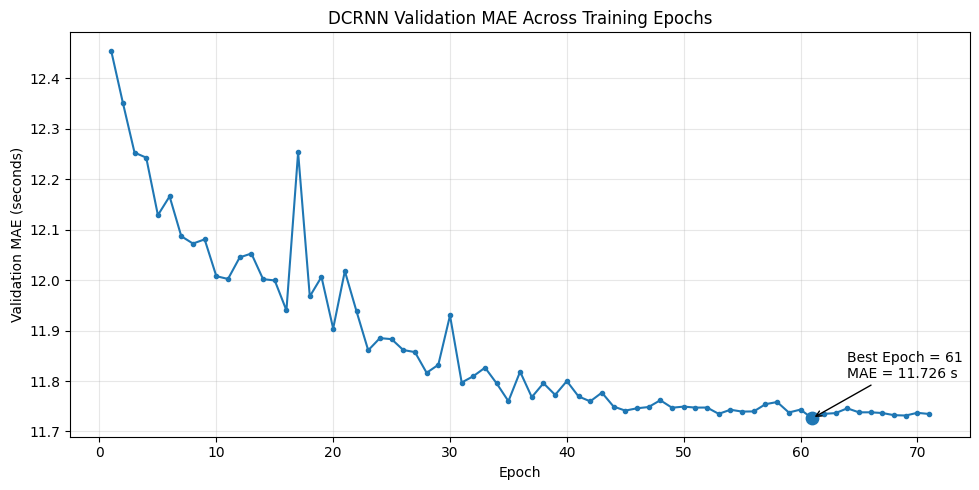

✅ Plot 1 saved


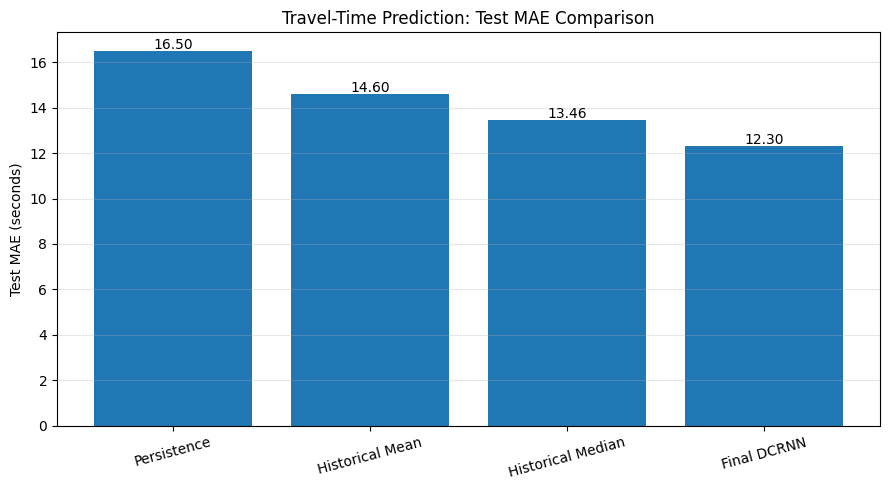

✅ Plot 2 saved

Generating test predictions...
Prediction points: 3635554


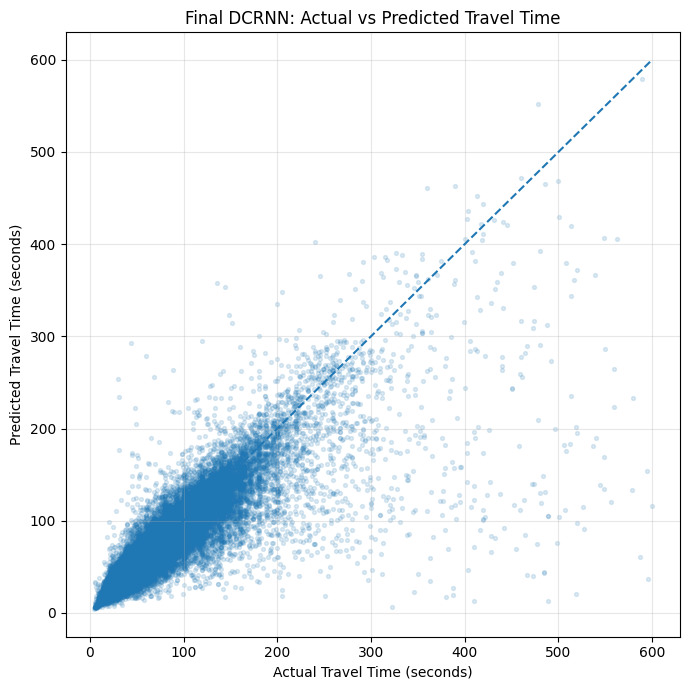

✅ Plot 3 saved


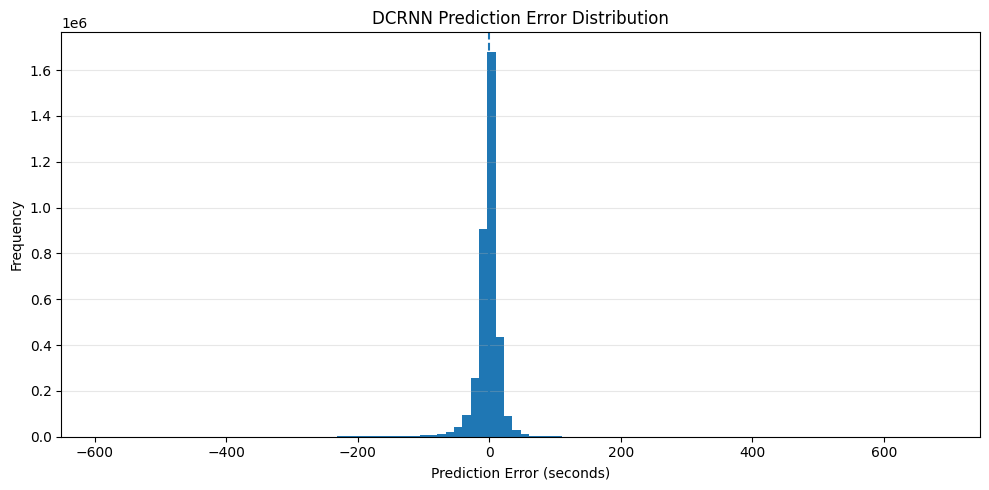

✅ Plot 4 saved

Adjacency matrix shape: (1000, 1000)
Directed edges: 929


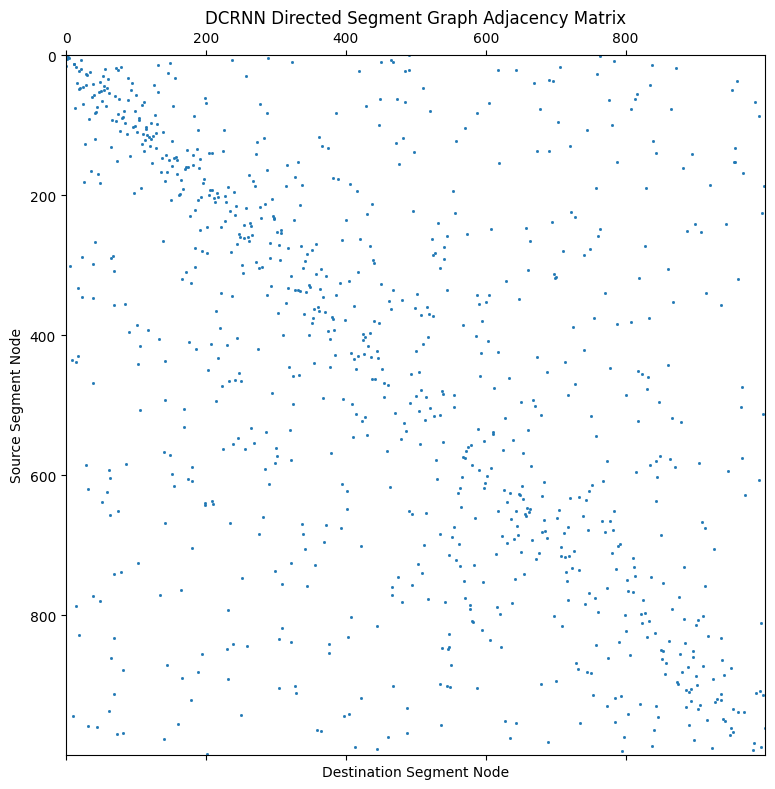

✅ Plot 5 saved

================ ALL FINAL PLOTS CREATED ================

Best validation epoch : 61
Best validation MAE   : 11.7260 s

Final test MAE        : 12.3009 s
Final test RMSE       : 26.0561 s
Final test R²         : 0.7369
Final test WAPE       : 16.9489 %

Files saved:

1. /kaggle/working/dcrnn_v1_20261006_044906/01_validation_mae_vs_epoch.png
2. /kaggle/working/dcrnn_v1_20261006_044906/02_test_mae_model_comparison.png
3. /kaggle/working/dcrnn_v1_20261006_044906/03_actual_vs_predicted.png
4. /kaggle/working/dcrnn_v1_20261006_044906/04_prediction_error_distribution.png
5. /kaggle/working/dcrnn_v1_20261006_044906/05_dcrnn_adjacency_matrix.png

DCRNN report visualizations complete ✅


In [65]:
# ===================== FINAL DCRNN REPORT PLOTS - ALL IN ONE CELL =====================

import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# ==========================================================
# PATHS
# ==========================================================

OUT_DIR = "/kaggle/working"
RUN_DIR = "/kaggle/working/dcrnn_v1_20261006_044906"

os.makedirs(RUN_DIR, exist_ok=True)

print("Creating final DCRNN plots...")


# ==========================================================
# PLOT 1 — VALIDATION MAE VS EPOCH
# ==========================================================

history_path = os.path.join(
    RUN_DIR,
    "training_history_v1.csv"
)

history = pd.read_csv(history_path)

best_idx = history["validation_MAE"].idxmin()

best_epoch = int(
    history.loc[best_idx, "epoch"]
)

best_mae = float(
    history.loc[best_idx, "validation_MAE"]
)

plt.figure(figsize=(10, 5))

plt.plot(
    history["epoch"],
    history["validation_MAE"],
    marker="o",
    markersize=3
)

plt.scatter(
    best_epoch,
    best_mae,
    s=80
)

plt.xlabel("Epoch")
plt.ylabel("Validation MAE (seconds)")

plt.title(
    "DCRNN Validation MAE Across Training Epochs"
)

plt.grid(
    True,
    alpha=0.3
)

plt.annotate(
    f"Best Epoch = {best_epoch}\nMAE = {best_mae:.3f} s",
    xy=(best_epoch, best_mae),
    xytext=(best_epoch + 3, best_mae + 0.08),
    arrowprops=dict(
        arrowstyle="->"
    )
)

plt.tight_layout()

plot1 = os.path.join(
    RUN_DIR,
    "01_validation_mae_vs_epoch.png"
)

plt.savefig(
    plot1,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Plot 1 saved")


# ==========================================================
# PLOT 2 — BASELINES VS FINAL DCRNN
# ==========================================================

comparison_path = os.path.join(
    RUN_DIR,
    "dcrnn_final_test_comparison.csv"
)

comparison = pd.read_csv(
    comparison_path
)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    comparison["Model"],
    comparison["MAE"]
)

plt.ylabel("Test MAE (seconds)")

plt.title(
    "Travel-Time Prediction: Test MAE Comparison"
)

plt.xticks(
    rotation=15
)

plt.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    comparison["MAE"]
):

    plt.text(
        bar.get_x()
        +
        bar.get_width() / 2,

        value + 0.1,

        f"{value:.2f}",

        ha="center"
    )

plt.tight_layout()

plot2 = os.path.join(
    RUN_DIR,
    "02_test_mae_model_comparison.png"
)

plt.savefig(
    plot2,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Plot 2 saved")


# ==========================================================
# GENERATE FINAL DCRNN TEST PREDICTIONS
# Required for Plots 3 and 4
# ==========================================================

FINAL_MODEL_PATH = (
    "/kaggle/working/dcrnn_v1_final_best.pt"
)

checkpoint = torch.load(
    FINAL_MODEL_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

actual_all = []
pred_all = []

print("\nGenerating test predictions...")

with torch.no_grad():

    for Xb, yb, mb in test_loader:

        Xb = Xb.to(
            device,
            non_blocking=True
        )

        yb = yb.to(
            device,
            non_blocking=True
        )

        mb = mb.to(
            device,
            non_blocking=True
        )

        pred_scaled = model(
            Xb,
            supports
        )

        pred_seconds = (
            pred_scaled
            * travel_std_t.unsqueeze(0)
            +
            travel_mean_t.unsqueeze(0)
        )

        valid = (
            (mb > 0)
            &
            torch.isfinite(yb)
        )

        actual_all.append(
            yb[valid]
            .detach()
            .cpu()
            .numpy()
        )

        pred_all.append(
            pred_seconds[valid]
            .detach()
            .cpu()
            .numpy()
        )


actual = np.concatenate(
    actual_all
)

predicted = np.concatenate(
    pred_all
)

errors = (
    predicted
    -
    actual
)

print(
    "Prediction points:",
    len(actual)
)


# ==========================================================
# PLOT 3 — ACTUAL VS PREDICTED
# ==========================================================

# Use a reproducible sample so millions of points
# do not make the plot unreadable.

rng = np.random.default_rng(42)

sample_size = min(
    50000,
    len(actual)
)

sample_idx = rng.choice(
    len(actual),
    size=sample_size,
    replace=False
)

actual_sample = actual[
    sample_idx
]

pred_sample = predicted[
    sample_idx
]


plt.figure(figsize=(7, 7))

plt.scatter(
    actual_sample,
    pred_sample,
    alpha=0.15,
    s=8
)

minimum = min(
    actual_sample.min(),
    pred_sample.min()
)

maximum = max(
    actual_sample.max(),
    pred_sample.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel(
    "Actual Travel Time (seconds)"
)

plt.ylabel(
    "Predicted Travel Time (seconds)"
)

plt.title(
    "Final DCRNN: Actual vs Predicted Travel Time"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plot3 = os.path.join(
    RUN_DIR,
    "03_actual_vs_predicted.png"
)

plt.savefig(
    plot3,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Plot 3 saved")


# ==========================================================
# PLOT 4 — PREDICTION ERROR DISTRIBUTION
# ==========================================================

# Error:
# predicted - actual
#
# 0 = perfect prediction
# positive = overprediction
# negative = underprediction

plt.figure(figsize=(10, 5))

plt.hist(
    errors,
    bins=100
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Prediction Error (seconds)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "DCRNN Prediction Error Distribution"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plot4 = os.path.join(
    RUN_DIR,
    "04_prediction_error_distribution.png"
)

plt.savefig(
    plot4,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Plot 4 saved")


# ==========================================================
# PLOT 5 — DCRNN GRAPH / ADJACENCY MATRIX
# ==========================================================

adjacency_path = os.path.join(
    OUT_DIR,
    "adjacency_matrix.npy"
)

adjacency = np.load(
    adjacency_path
)

print(
    "\nAdjacency matrix shape:",
    adjacency.shape
)

print(
    "Directed edges:",
    int(np.count_nonzero(adjacency))
)


plt.figure(figsize=(8, 8))

plt.spy(
    adjacency,
    markersize=1
)

plt.xlabel(
    "Destination Segment Node"
)

plt.ylabel(
    "Source Segment Node"
)

plt.title(
    "DCRNN Directed Segment Graph Adjacency Matrix"
)

plt.tight_layout()

plot5 = os.path.join(
    RUN_DIR,
    "05_dcrnn_adjacency_matrix.png"
)

plt.savefig(
    plot5,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Plot 5 saved")


# ==========================================================
# FINAL SUMMARY
# ==========================================================

print(
    "\n================ ALL FINAL PLOTS CREATED ================"
)

print(
    f"""
Best validation epoch : {best_epoch}
Best validation MAE   : {best_mae:.4f} s

Final test MAE        : 12.3009 s
Final test RMSE       : 26.0561 s
Final test R²         : 0.7369
Final test WAPE       : 16.9489 %

Files saved:

1. {plot1}
2. {plot2}
3. {plot3}
4. {plot4}
5. {plot5}
"""
)

print(
    "DCRNN report visualizations complete ✅"
)

In [71]:
import pandas as pd
from IPython.display import display, HTML

# =========================================================
# CHANGE THIS PATH TO YOUR RESULT CSV
# =========================================================
input_path = "/kaggle/working/dcrnn_v1_20261006_044906/final_travel_time_eta_results.csv"

# Load values from your actual saved model output
df = pd.read_csv(input_path)

# ---------------------------------------------------------
# Clean / rename columns only if needed
# ---------------------------------------------------------
rename_map = {
    "MAE (s)": "MAE",
    "RMSE (s)": "RMSE",
    "WAPE (%)": "WAPE"
}
df = df.rename(columns=rename_map)

# ---------------------------------------------------------
# Format WAPE as percentage only if it is numeric
# ---------------------------------------------------------
if "WAPE" in df.columns and pd.api.types.is_numeric_dtype(df["WAPE"]):
    df["WAPE"] = df["WAPE"].map(lambda x: f"{x:.2f}%")

# ---------------------------------------------------------
# Styling like your screenshot
# ---------------------------------------------------------
styled = (
    df.style
    .set_caption("FINAL MODEL COMPARISON")
    .format({
        "MAE": "{:.3f}" if "MAE" in df.columns else None,
        "RMSE": "{:.3f}" if "RMSE" in df.columns else None,
        "MSE": "{:.3f}" if "MSE" in df.columns else None,
        "R²": "{:.4f}" if "R²" in df.columns else None,
        "R2": "{:.4f}" if "R2" in df.columns else None,
        "MAPE (%)": "{:.2f}" if "MAPE (%)" in df.columns and pd.api.types.is_numeric_dtype(df["MAPE (%)"]) else None,
        "MAPE": "{:.2f}" if "MAPE" in df.columns and pd.api.types.is_numeric_dtype(df["MAPE"]) else None,
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("text-align", "left"),
                ("font-size", "24px"),
                ("font-weight", "bold"),
                ("color", "white"),
                ("padding", "12px 0px 16px 0px"),
            ],
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "10px 0"),
                ("font-size", "16px"),
                ("min-width", "850px"),
                ("background-color", "#111111"),
                ("color", "white"),
            ],
        },
        {
            "selector": "thead th",
            "props": [
                ("background-color", "#111111"),
                ("color", "white"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border-bottom", "2px solid #888"),
                ("padding", "12px"),
            ],
        },
        {
            "selector": "tbody td",
            "props": [
                ("padding", "12px"),
                ("text-align", "center"),
                ("font-size", "16px"),
                ("border", "none"),
            ],
        },
        {
            "selector": "tbody th",
            "props": [
                ("padding", "12px"),
                ("text-align", "center"),
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("color", "white"),
                ("border", "none"),
            ],
        },
        {
            "selector": "tbody tr:nth-child(odd)",
            "props": [("background-color", "#000000")],
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [("background-color", "#1a1a1a")],
        },
    ])
    .set_properties(**{
        "color": "white",
        "background-color": "#111111",
    })
)

print("=" * 95)
print("FINAL MODEL COMPARISON")
print("=" * 95)

display(styled)

FINAL MODEL COMPARISON


,Model,MAE,RMSE,MSE,R²,WAPE,MAPE (%)
0,Persistence,16.495,33.011,1089.739,0.5777,22.73%,23.96
1,Historical Mean,14.597,29.145,849.433,0.6708,20.11%,20.90
2,Historical Median,13.462,29.599,876.087,0.6605,18.55%,17.86
3,Final DCRNN,12.301,26.056,678.918,0.7369,16.95%,nan
